# LIBs

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder,RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# load data

In [6]:
data=pd.read_csv('preeclampsia_data.csv')
data.head()

,patient_id,age,age_category,parity,gravida,bmi,bmi_category,gestational_age_weeks,residence,education,...,fetal_growth_restriction,placental_abruption,acute_kidney_injury,pulmonary_edema,stroke,delivery_mode,magnesium_sulfate_given,antihypertensive_given,maternal_outcome,maternal_death
0,PE_000001,30,30-34,0,1,22.9,Normal,36,Rural,Primary,...,False,False,False,False,False,Vaginal,False,True,Survived,False
1,PE_000002,25,20-29,1,1,26.7,Overweight,35,Rural,Primary,...,False,False,False,False,False,C-section,False,False,Survived,False
2,PE_000003,21,20-29,0,1,21.3,Normal,32,Urban,NaN,...,True,False,False,False,False,C-section,True,True,Survived,False
3,PE_000004,23,20-29,2,2,21.3,Normal,35,Rural,Secondary,...,False,False,False,False,False,Vaginal,False,False,Survived,False
4,PE_000005,32,30-34,4,5,34.0,Obese,33,Urban,Primary,...,False,False,False,False,False,Vaginal,False,False,Survived,False


In [7]:
data.shape

(10000, 47)

In [8]:
data.columns

Index(['patient_id', 'age', 'age_category', 'parity', 'gravida', 'bmi',
       'bmi_category', 'gestational_age_weeks', 'residence', 'education',
       'antenatal_visits', 'chronic_hypertension', 'pregestational_diabetes',
       'chronic_kidney_disease', 'multiple_pregnancy', 'previous_preeclampsia',
       'family_history_preeclampsia', 'antiphospholipid_syndrome',
       'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'proteinuria_24h_mg',
       'platelets_k_ul', 'ast_u_l', 'alt_u_l', 'creatinine_mg_dl', 'ldh_u_l',
       'uric_acid_mg_dl', 'hemoglobin_g_dl', 'preeclampsia_status', 'severity',
       'hellp_syndrome', 'eclampsia', 'headache', 'visual_disturbances',
       'epigastric_pain', 'edema', 'nausea_vomiting',
       'fetal_growth_restriction', 'placental_abruption',
       'acute_kidney_injury', 'pulmonary_edema', 'stroke', 'delivery_mode',
       'magnesium_sulfate_given', 'antihypertensive_given', 'maternal_outcome',
       'maternal_death'],
      dtype='object')

In [9]:
data.dtypes

patient_id                      object
age                              int64
age_category                    object
parity                           int64
gravida                          int64
bmi                            float64
bmi_category                    object
gestational_age_weeks            int64
residence                       object
education                       object
antenatal_visits                 int64
chronic_hypertension              bool
pregestational_diabetes           bool
chronic_kidney_disease            bool
multiple_pregnancy                bool
previous_preeclampsia             bool
family_history_preeclampsia       bool
antiphospholipid_syndrome         bool
systolic_bp_mmhg               float64
diastolic_bp_mmhg              float64
proteinuria_24h_mg             float64
platelets_k_ul                 float64
ast_u_l                        float64
alt_u_l                        float64
creatinine_mg_dl               float64
ldh_u_l                  

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   patient_id                   10000 non-null  object 
 1   age                          10000 non-null  int64  
 2   age_category                 10000 non-null  object 
 3   parity                       10000 non-null  int64  
 4   gravida                      10000 non-null  int64  
 5   bmi                          10000 non-null  float64
 6   bmi_category                 10000 non-null  object 
 7   gestational_age_weeks        10000 non-null  int64  
 8   residence                    10000 non-null  object 
 9   education                    7925 non-null   object 
 10  antenatal_visits             10000 non-null  int64  
 11  chronic_hypertension         10000 non-null  bool   
 12  pregestational_diabetes      10000 non-null  bool   
 13  chronic_kidney_di

In [11]:
data.describe()

,age,parity,gravida,bmi,gestational_age_weeks,antenatal_visits,systolic_bp_mmhg,diastolic_bp_mmhg,proteinuria_24h_mg,platelets_k_ul,ast_u_l,alt_u_l,creatinine_mg_dl,ldh_u_l,uric_acid_mg_dl,hemoglobin_g_dl
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,28.758600,1.957100,2.932400,24.616770,34.488200,2.611500,135.028190,82.803680,1237.561900,207.196300,42.016730,34.693570,0.807764,355.914100,5.085230,11.138050
std,7.582472,2.302344,2.626694,4.360198,3.429204,1.776481,23.435821,15.315422,1760.959082,73.580973,34.200055,24.100297,0.277889,167.631391,1.524995,1.172645
min,15.000000,0.000000,1.000000,16.000000,22.000000,0.000000,90.000000,60.000000,0.000000,30.000000,15.000000,15.000000,0.400000,150.000000,2.500000,6.000000
25%,22.000000,0.000000,1.000000,21.500000,32.000000,1.000000,115.900000,70.100000,102.000000,154.000000,21.400000,18.800000,0.620000,242.000000,4.000000,10.400000
50%,30.000000,1.000000,2.000000,24.600000,35.000000,2.000000,127.200000,79.700000,195.000000,207.000000,29.150000,25.400000,0.750000,312.000000,4.800000,11.200000
75%,34.000000,3.000000,4.000000,27.600000,37.000000,4.000000,160.000000,94.600000,2218.250000,259.000000,45.000000,38.900000,0.910000,409.000000,6.100000,12.000000
max,49.000000,8.000000,11.000000,43.800000,42.000000,12.000000,206.300000,129.800000,8865.000000,450.000000,263.100000,158.400000,2.540000,1391.000000,11.300000,13.500000


# Data Understanding (EDA)

##  Target Distribution

In [12]:
data.preeclampsia_status.unique()

array(['Positive', 'Negative'], dtype=object)

In [13]:
data.preeclampsia_status.value_counts()

preeclampsia_status
Negative    6059
Positive    3941
Name: count, dtype: int64

##  Data Quality Check

In [14]:
data.isna().sum()

patient_id                        0
age                               0
age_category                      0
parity                            0
gravida                           0
bmi                               0
bmi_category                      0
gestational_age_weeks             0
residence                         0
education                      2075
antenatal_visits                  0
chronic_hypertension              0
pregestational_diabetes           0
chronic_kidney_disease            0
multiple_pregnancy                0
previous_preeclampsia             0
family_history_preeclampsia       0
antiphospholipid_syndrome         0
systolic_bp_mmhg                  0
diastolic_bp_mmhg                 0
proteinuria_24h_mg                0
platelets_k_ul                    0
ast_u_l                           0
alt_u_l                           0
creatinine_mg_dl                  0
ldh_u_l                           0
uric_acid_mg_dl                   0
hemoglobin_g_dl             

In [15]:
data.duplicated().sum()

np.int64(0)

In [16]:
data.severity.value_counts()

severity
Severe    3105
Mild       836
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

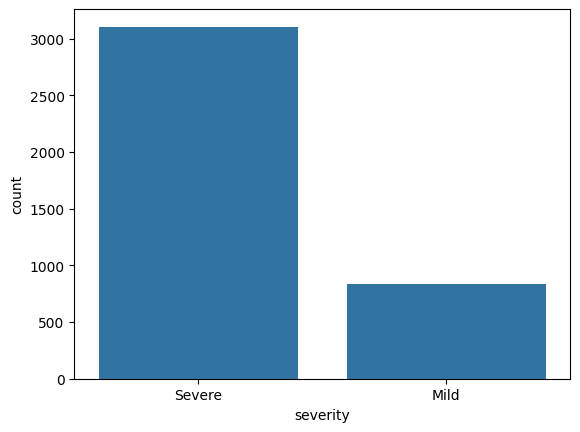

In [17]:
sns.countplot(x=data.severity)
plt.show

<Axes: xlabel='severity', ylabel='count'>

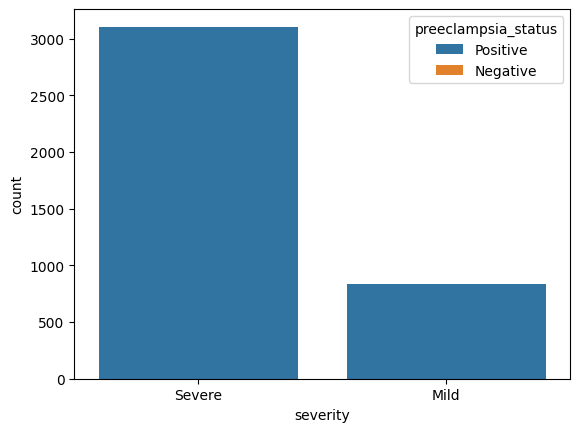

In [18]:
sns.countplot(x=data.severity ,hue=data.preeclampsia_status)

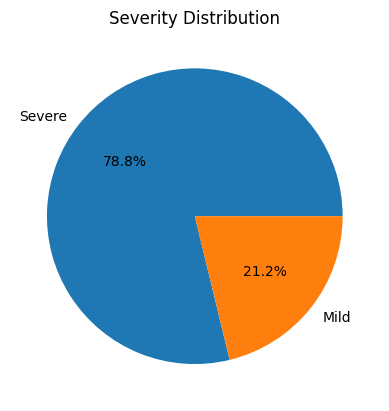

In [19]:
plt.pie(data['severity'].value_counts(), labels=data['severity'].value_counts().index, autopct='%1.1f%%')
plt.title('Severity Distribution')
plt.show()

### handling missing value

In [20]:
data['severity'] = data['severity'].fillna('safe')

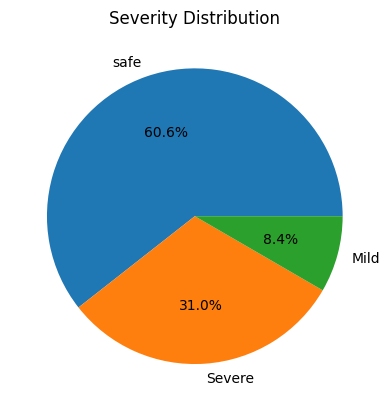

In [21]:
plt.pie(data['severity'].value_counts(), labels=data['severity'].value_counts().index, autopct='%1.1f%%')
plt.title('Severity Distribution')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

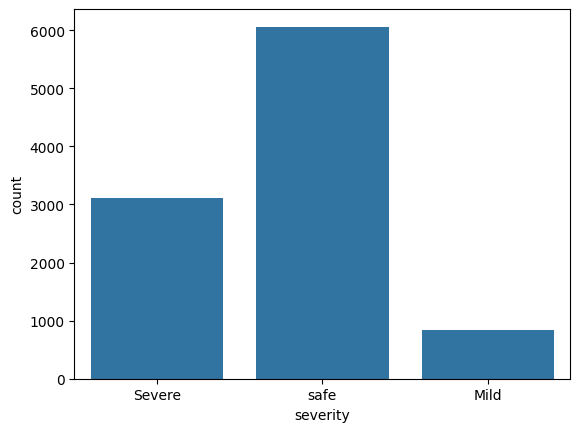

In [22]:
sns.countplot(x=data.severity)
plt.show

<Axes: xlabel='severity', ylabel='count'>

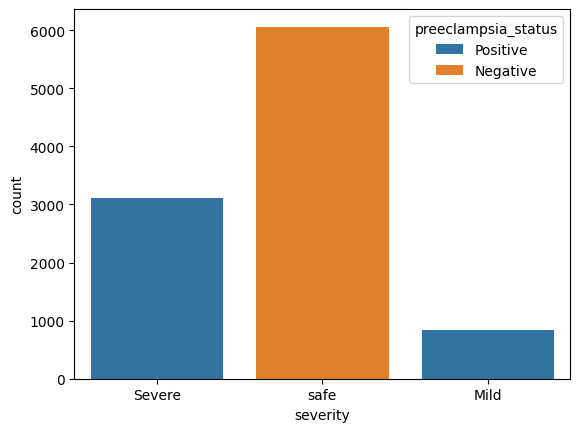

In [23]:
sns.countplot(x=data.severity ,hue=data.preeclampsia_status)

## Numerical Analysis

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   patient_id                   10000 non-null  object 
 1   age                          10000 non-null  int64  
 2   age_category                 10000 non-null  object 
 3   parity                       10000 non-null  int64  
 4   gravida                      10000 non-null  int64  
 5   bmi                          10000 non-null  float64
 6   bmi_category                 10000 non-null  object 
 7   gestational_age_weeks        10000 non-null  int64  
 8   residence                    10000 non-null  object 
 9   education                    7925 non-null   object 
 10  antenatal_visits             10000 non-null  int64  
 11  chronic_hypertension         10000 non-null  bool   
 12  pregestational_diabetes      10000 non-null  bool   
 13  chronic_kidney_di

In [25]:
numerical_cols = ['parity', 'gravida', 'gestational_age_weeks', 'antenatal_visits',
'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'proteinuria_24h_mg',
'platelets_k_ul', 'ast_u_l', 'alt_u_l', 'creatinine_mg_dl',
'ldh_u_l', 'uric_acid_mg_dl', 'hemoglobin_g_dl']

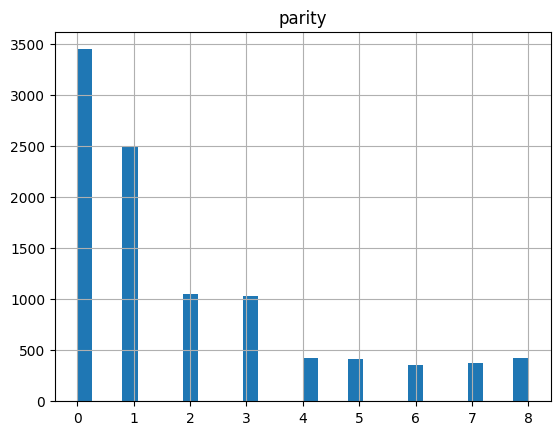

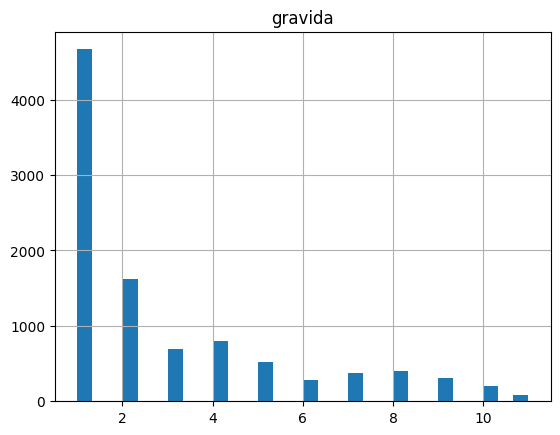

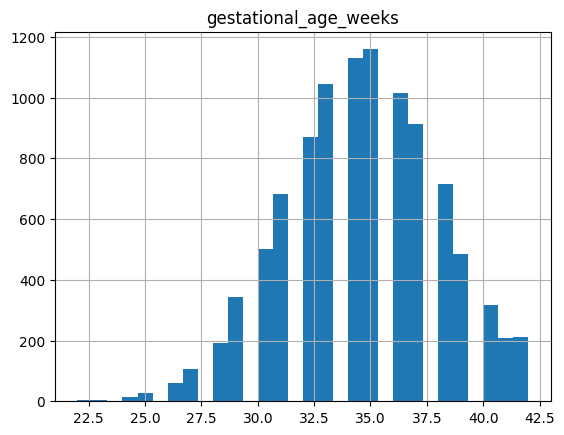

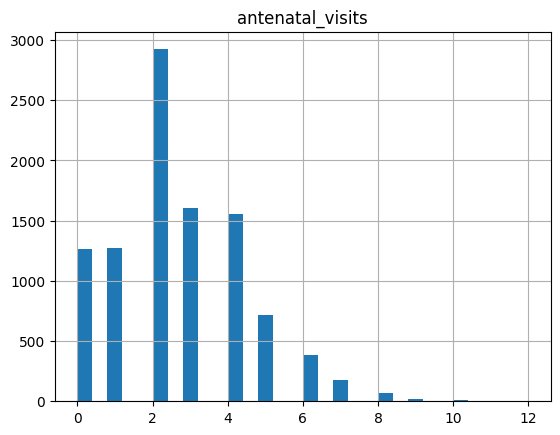

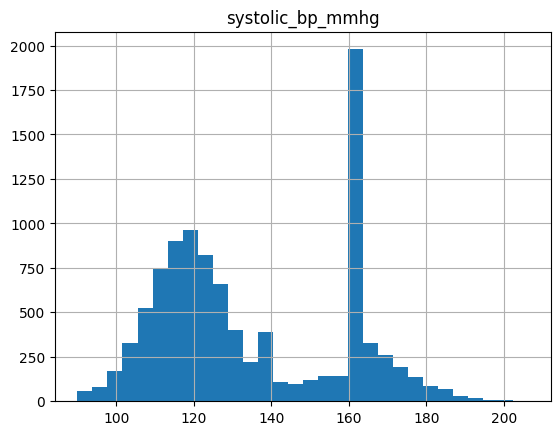

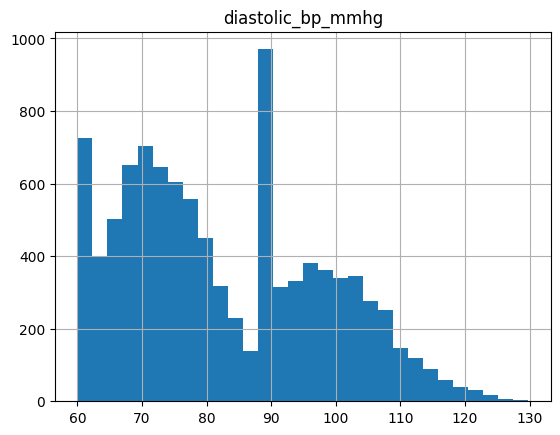

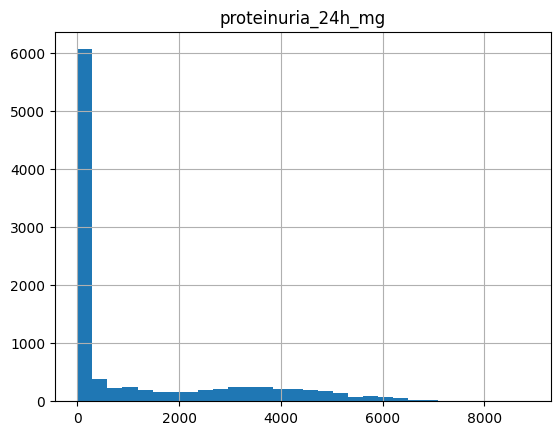

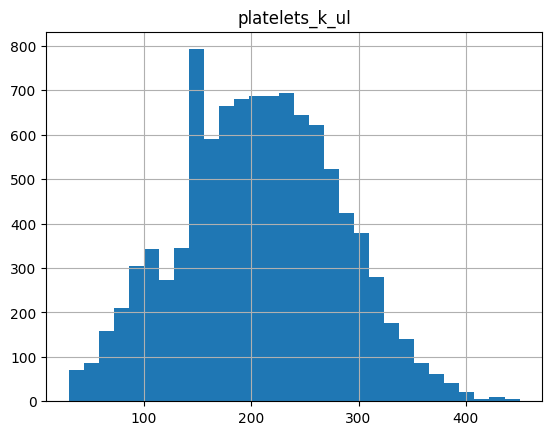

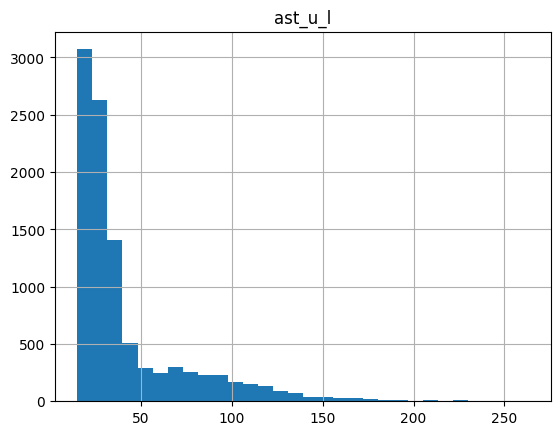

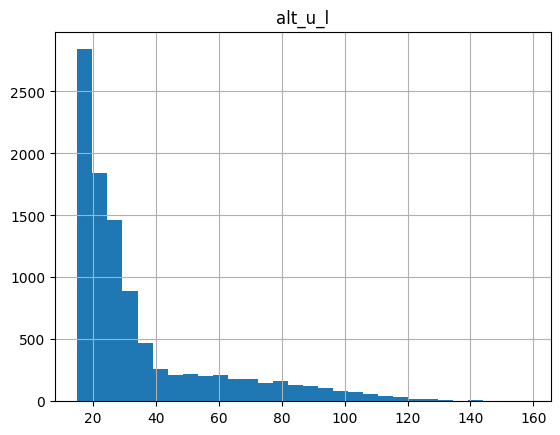

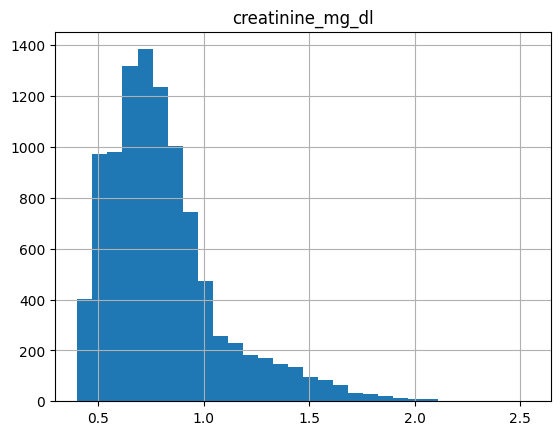

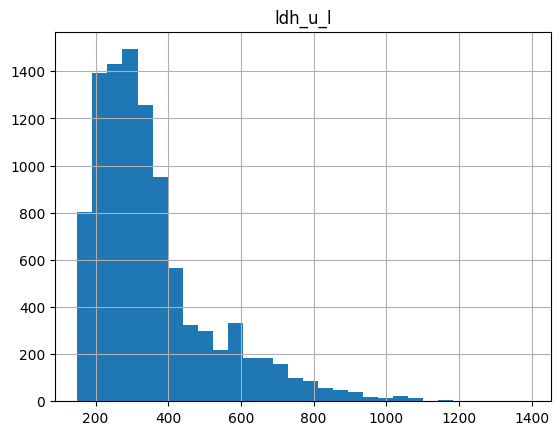

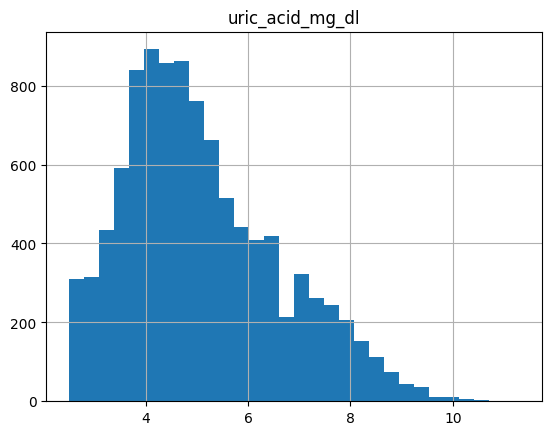

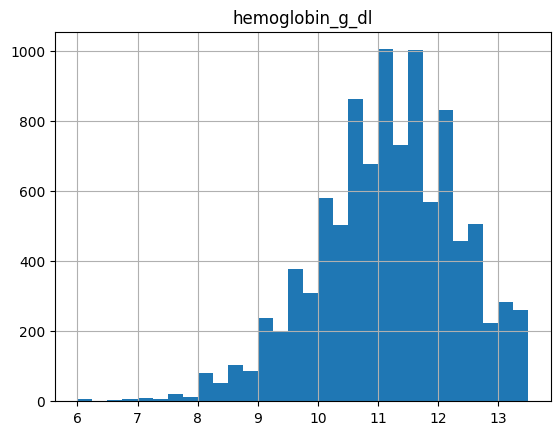

In [26]:
for col in numerical_cols:
    data[col].hist(bins=30)
    plt.title(col)
    plt.show()

In [27]:
#طب بص الكلوريشين بين دول عالي اوي مش عارف بقي هيفرق معاك ولا لا بس يعتبر هما الاتنين واحد كده كده مش محتاجه اصلا 
data[['gravida', 'parity']].corr()

,gravida,parity
gravida,1.000000,0.962684
parity,0.962684,1.000000


<Axes: xlabel='antenatal_visits', ylabel='count'>

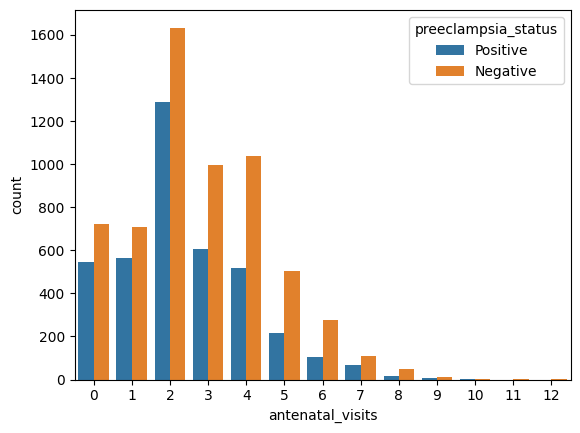

In [28]:
sns.countplot(x='antenatal_visits', hue='preeclampsia_status', data=data)

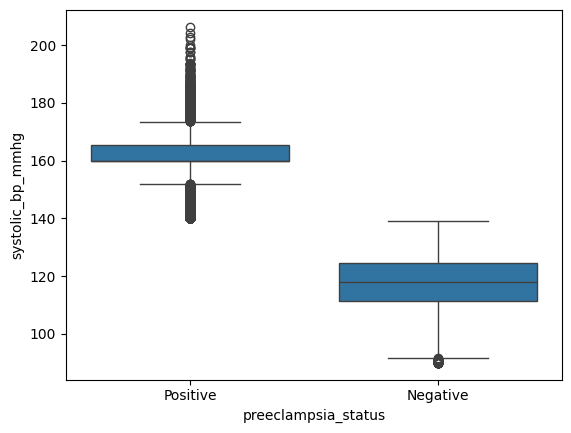

In [29]:
sns.boxplot(x='preeclampsia_status', y='systolic_bp_mmhg', data=data)
plt.show()

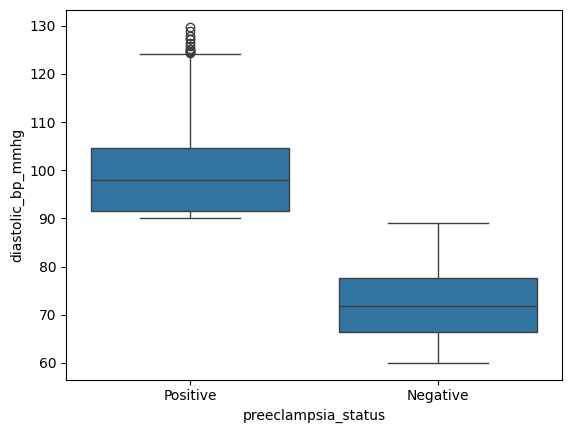

In [30]:
sns.boxplot(x='preeclampsia_status', y='diastolic_bp_mmhg', data=data)
plt.show()

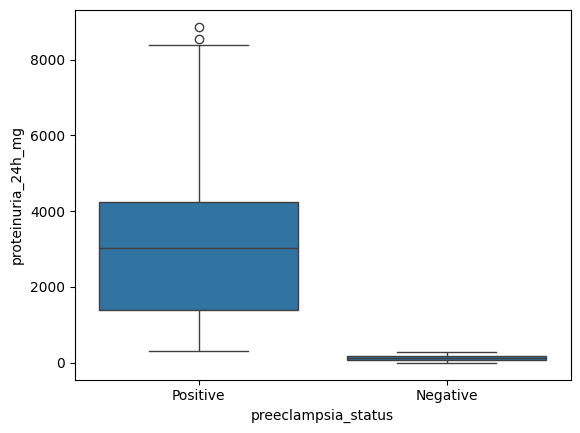

In [31]:
sns.boxplot(x='preeclampsia_status', y='proteinuria_24h_mg', data=data)
plt.show()

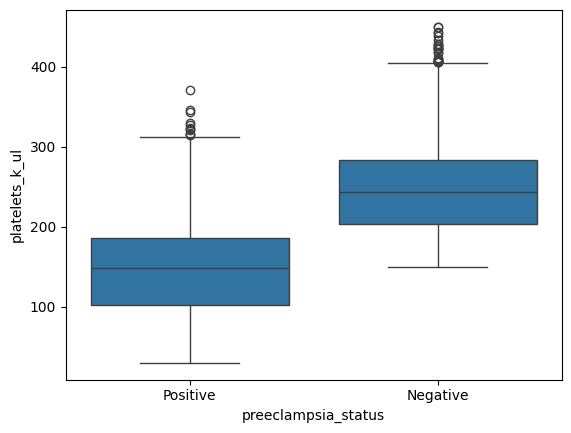

In [32]:
sns.boxplot(x='preeclampsia_status', y='platelets_k_ul', data=data)
plt.show()

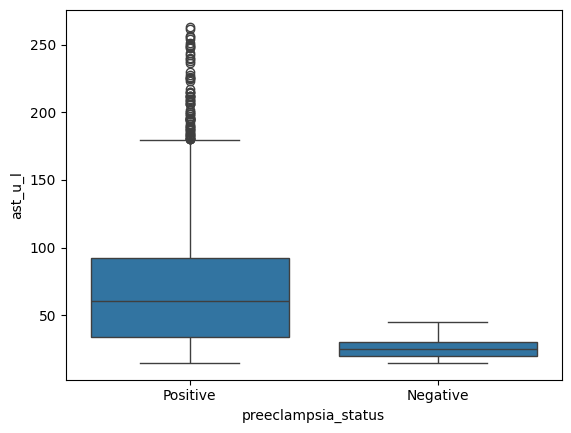

In [33]:
sns.boxplot(x='preeclampsia_status', y='ast_u_l', data=data)
plt.show()

In [34]:
data[['alt_u_l', 'ast_u_l']].corr()

,alt_u_l,ast_u_l
alt_u_l,1.00000,0.50652
ast_u_l,0.50652,1.00000


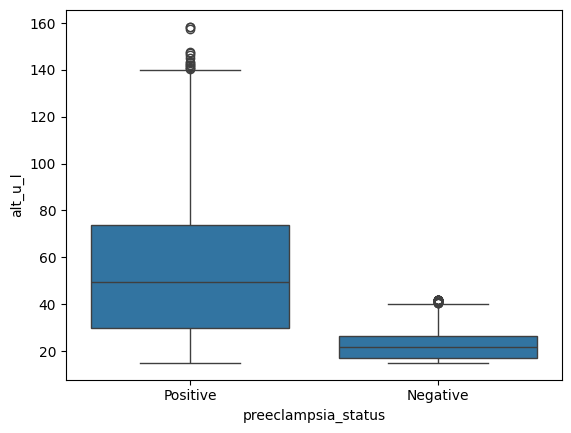

In [35]:
sns.boxplot(x='preeclampsia_status', y='alt_u_l', data=data)
plt.show()

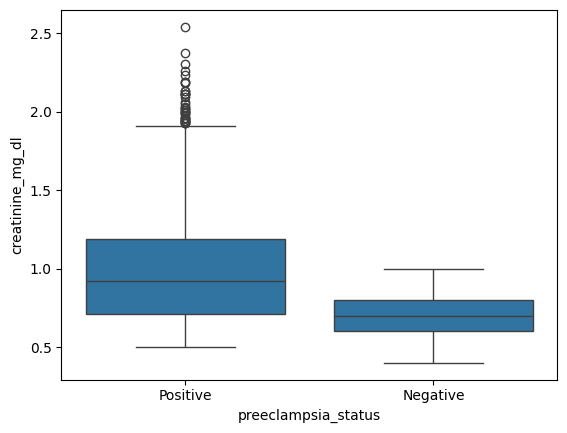

In [36]:
sns.boxplot(x='preeclampsia_status', y='creatinine_mg_dl', data=data)
plt.show()

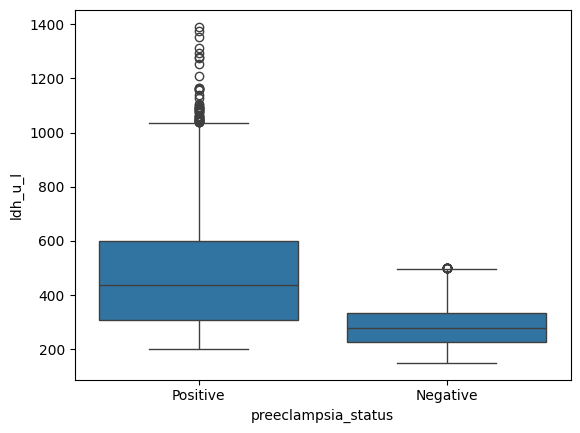

In [37]:
sns.boxplot(x='preeclampsia_status', y='ldh_u_l', data=data)
plt.show()

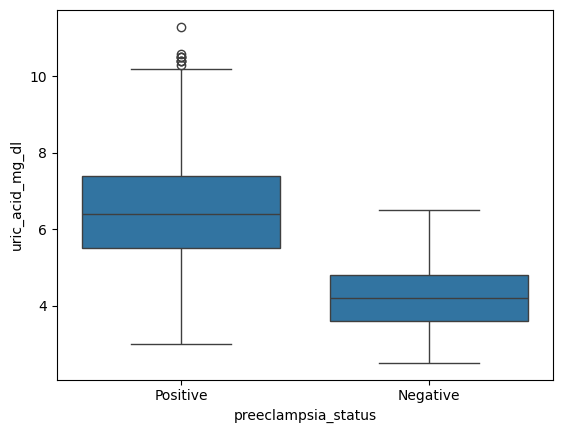

In [38]:
sns.boxplot(x='preeclampsia_status', y='uric_acid_mg_dl', data=data)
plt.show()

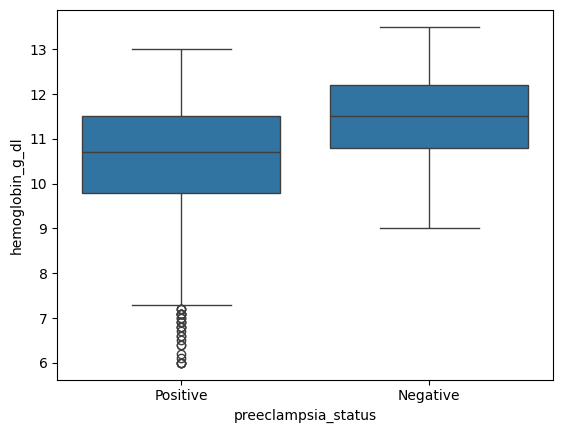

In [39]:
sns.boxplot(x='preeclampsia_status', y='hemoglobin_g_dl', data=data)
plt.show()

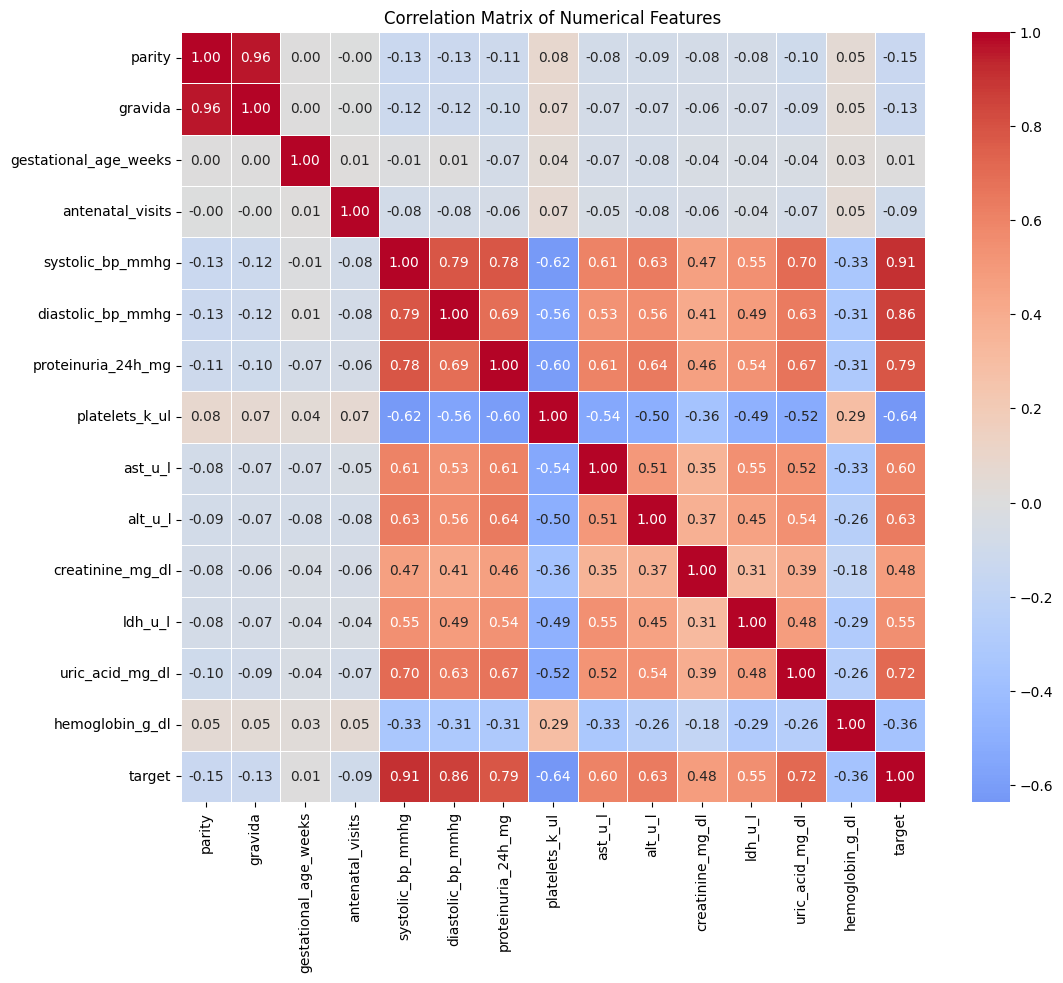

In [40]:
plt.figure(figsize=(12, 10))
df_corr = data[numerical_cols].copy()
df_corr['target'] = (data['preeclampsia_status'] == 'Positive').astype(int)
corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Categorical Features EDA

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   patient_id                   10000 non-null  object 
 1   age                          10000 non-null  int64  
 2   age_category                 10000 non-null  object 
 3   parity                       10000 non-null  int64  
 4   gravida                      10000 non-null  int64  
 5   bmi                          10000 non-null  float64
 6   bmi_category                 10000 non-null  object 
 7   gestational_age_weeks        10000 non-null  int64  
 8   residence                    10000 non-null  object 
 9   education                    7925 non-null   object 
 10  antenatal_visits             10000 non-null  int64  
 11  chronic_hypertension         10000 non-null  bool   
 12  pregestational_diabetes      10000 non-null  bool   
 13  chronic_kidney_di

In [42]:
categorical_cols = [
    # Categorical
    'age_category',
    'bmi_category',
    'residence',
    'severity',
    
    # Binary (Boolean)
    'chronic_hypertension',
    'pregestational_diabetes',
    'chronic_kidney_disease',
    'multiple_pregnancy',
    'previous_preeclampsia',
    'family_history_preeclampsia',
    'antiphospholipid_syndrome',
    'headache',
    'visual_disturbances',
    'epigastric_pain',
    'edema',
    'nausea_vomiting',
    'hellp_syndrome',
    'eclampsia',
    'fetal_growth_restriction',
    'placental_abruption',
    'acute_kidney_injury',
    'pulmonary_edema',
    'stroke'
]


age_category vs Target
Counts:
 preeclampsia_status  Negative  Positive
age_category                           
15-19                     936       534
20-29                    2006      1086
30-34                    1929      1016
35+                      1188      1305

Percentages:
 preeclampsia_status  Negative  Positive
age_category                           
15-19                    63.7      36.3
20-29                    64.9      35.1
30-34                    65.5      34.5
35+                      47.7      52.3


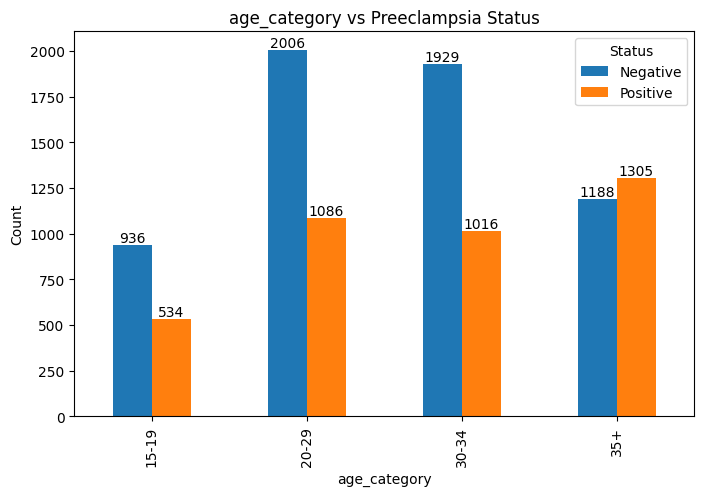


bmi_category vs Target
Counts:
 preeclampsia_status  Negative  Positive
bmi_category                           
Normal                   2883      1653
Obese                     460       661
Overweight               2178      1318
Underweight               538       309

Percentages:
 preeclampsia_status  Negative  Positive
bmi_category                           
Normal                   63.6      36.4
Obese                    41.0      59.0
Overweight               62.3      37.7
Underweight              63.5      36.5


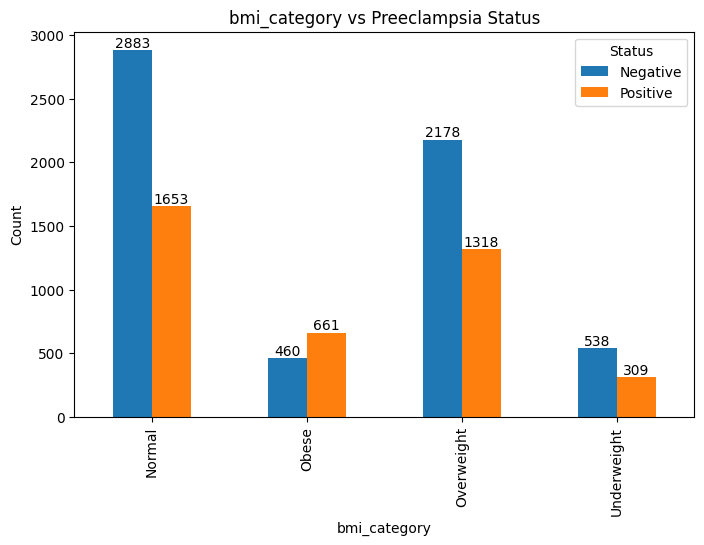


residence vs Target
Counts:
 preeclampsia_status  Negative  Positive
residence                              
Rural                    3425      2633
Urban                    2634      1308

Percentages:
 preeclampsia_status  Negative  Positive
residence                              
Rural                    56.5      43.5
Urban                    66.8      33.2


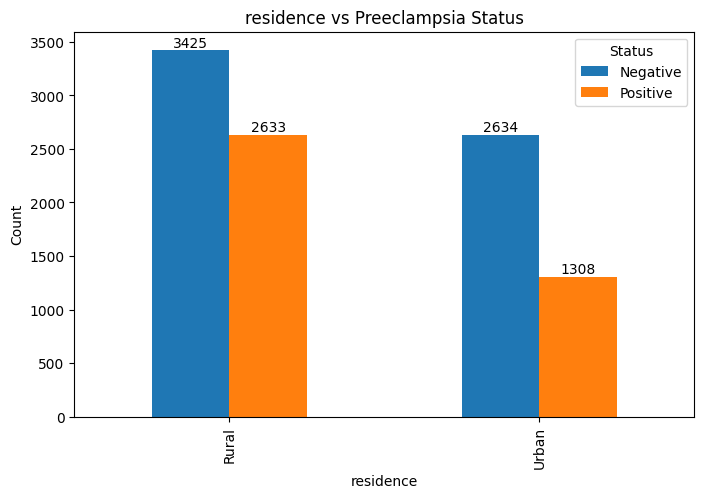


severity vs Target
Counts:
 preeclampsia_status  Negative  Positive
severity                               
Mild                        0       836
Severe                      0      3105
safe                     6059         0

Percentages:
 preeclampsia_status  Negative  Positive
severity                               
Mild                      0.0     100.0
Severe                    0.0     100.0
safe                    100.0       0.0


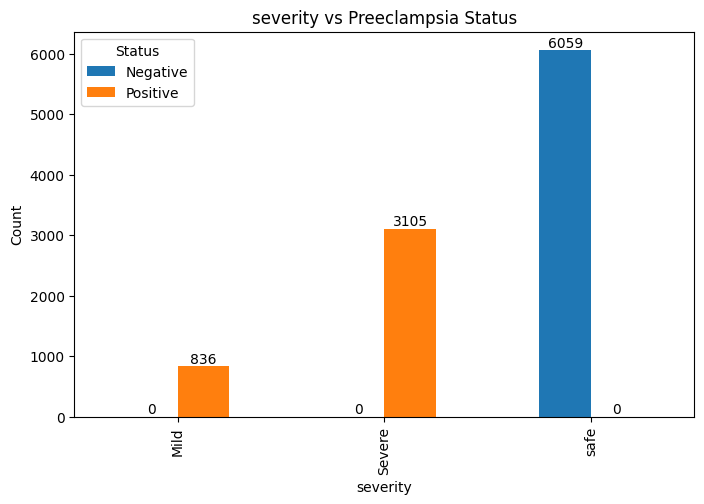


chronic_hypertension vs Target
Counts:
 preeclampsia_status   Negative  Positive
chronic_hypertension                    
False                     5860      3347
True                       199       594

Percentages:
 preeclampsia_status   Negative  Positive
chronic_hypertension                    
False                     63.6      36.4
True                      25.1      74.9


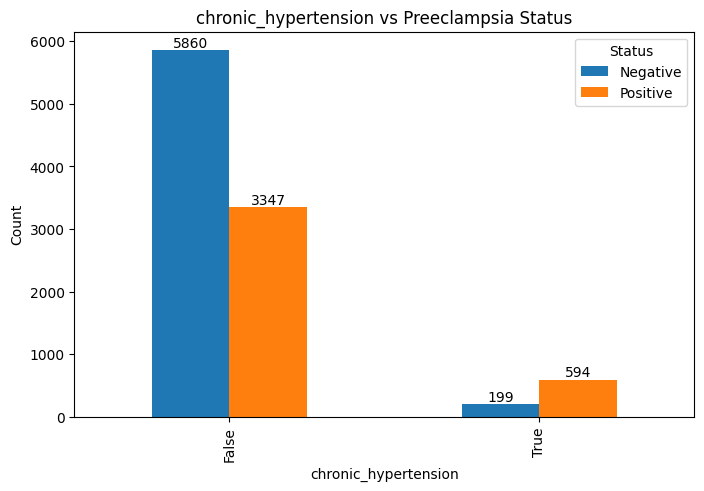


pregestational_diabetes vs Target
Counts:
 preeclampsia_status      Negative  Positive
pregestational_diabetes                    
False                        5920      3682
True                          139       259

Percentages:
 preeclampsia_status      Negative  Positive
pregestational_diabetes                    
False                        61.7      38.3
True                         34.9      65.1


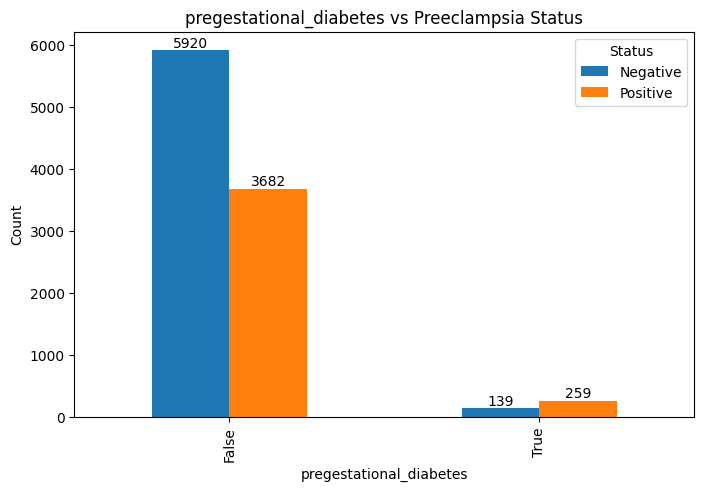


chronic_kidney_disease vs Target
Counts:
 preeclampsia_status     Negative  Positive
chronic_kidney_disease                    
False                       6019      3780
True                          40       161

Percentages:
 preeclampsia_status     Negative  Positive
chronic_kidney_disease                    
False                       61.4      38.6
True                        19.9      80.1


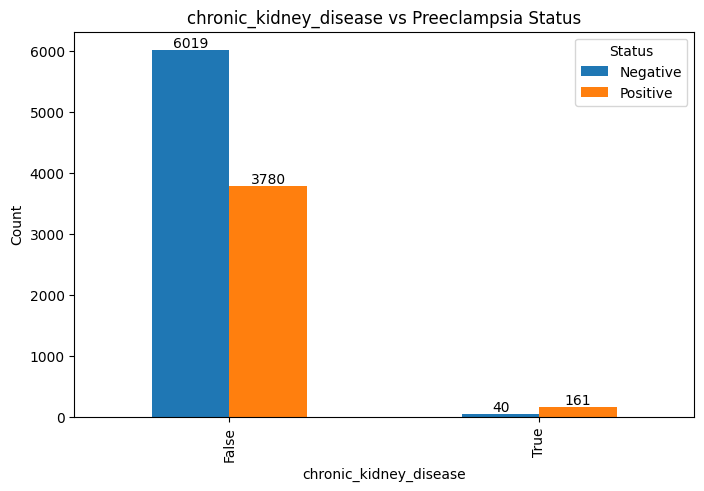


multiple_pregnancy vs Target
Counts:
 preeclampsia_status  Negative  Positive
multiple_pregnancy                     
False                    5963      3739
True                       96       202

Percentages:
 preeclampsia_status  Negative  Positive
multiple_pregnancy                     
False                    61.5      38.5
True                     32.2      67.8


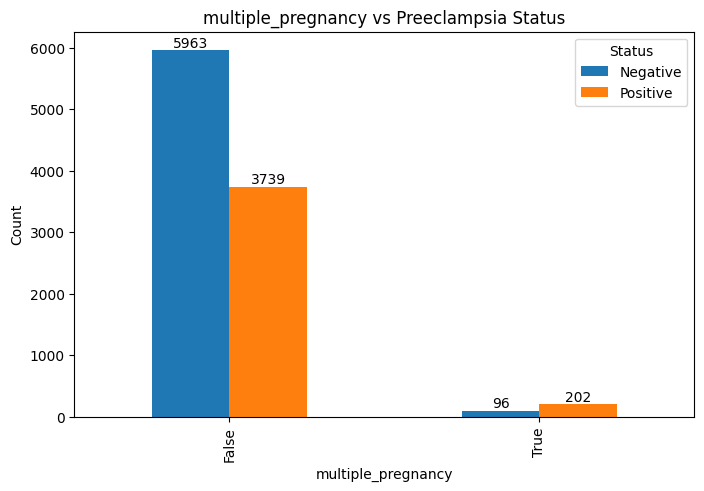


previous_preeclampsia vs Target
Counts:
 preeclampsia_status    Negative  Positive
previous_preeclampsia                    
False                      6005      3710
True                         54       231

Percentages:
 preeclampsia_status    Negative  Positive
previous_preeclampsia                    
False                      61.8      38.2
True                       18.9      81.1


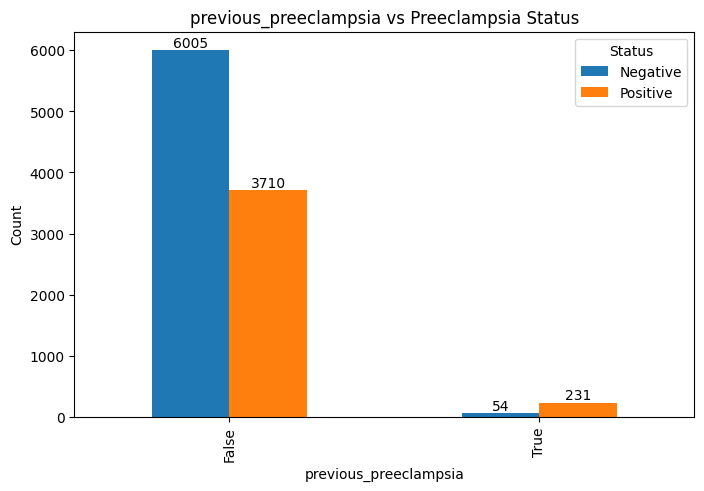


family_history_preeclampsia vs Target
Counts:
 preeclampsia_status          Negative  Positive
family_history_preeclampsia                    
False                            5618      3138
True                              441       803

Percentages:
 preeclampsia_status          Negative  Positive
family_history_preeclampsia                    
False                            64.2      35.8
True                             35.5      64.5


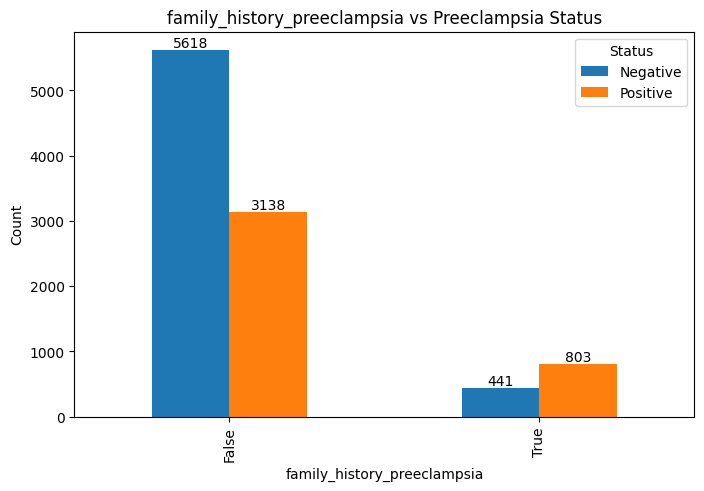


antiphospholipid_syndrome vs Target
Counts:
 preeclampsia_status        Negative  Positive
antiphospholipid_syndrome                    
False                          6043      3848
True                             16        93

Percentages:
 preeclampsia_status        Negative  Positive
antiphospholipid_syndrome                    
False                          61.1      38.9
True                           14.7      85.3


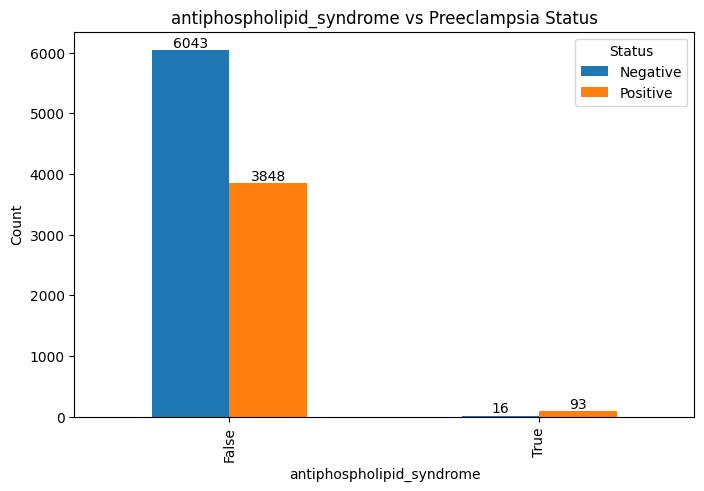


headache vs Target
Counts:
 preeclampsia_status  Negative  Positive
headache                               
False                    4860       891
True                     1199      3050

Percentages:
 preeclampsia_status  Negative  Positive
headache                               
False                    84.5      15.5
True                     28.2      71.8


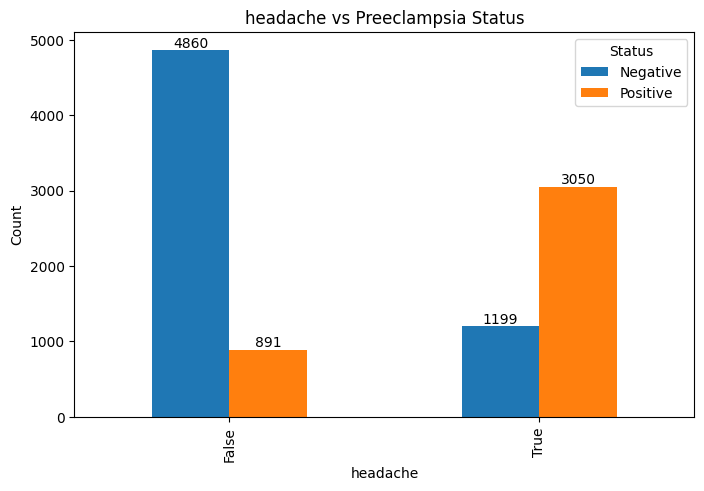


visual_disturbances vs Target
Counts:
 preeclampsia_status  Negative  Positive
visual_disturbances                    
False                    6059      1896
True                        0      2045

Percentages:
 preeclampsia_status  Negative  Positive
visual_disturbances                    
False                    76.2      23.8
True                      0.0     100.0


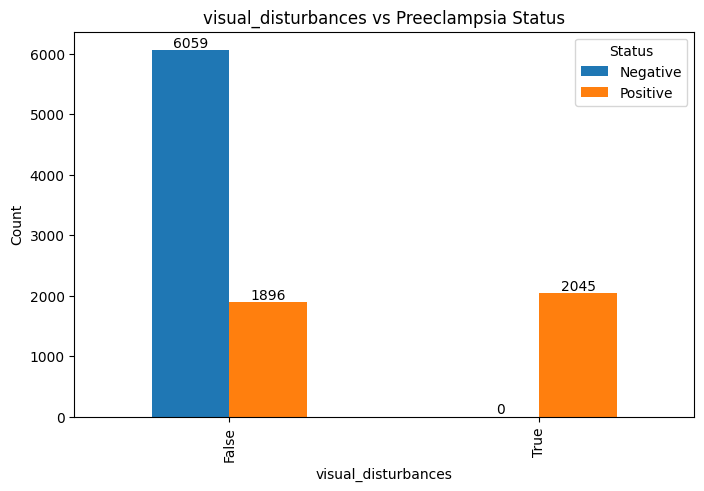


epigastric_pain vs Target
Counts:
 preeclampsia_status  Negative  Positive
epigastric_pain                        
False                    5465      2398
True                      594      1543

Percentages:
 preeclampsia_status  Negative  Positive
epigastric_pain                        
False                    69.5      30.5
True                     27.8      72.2


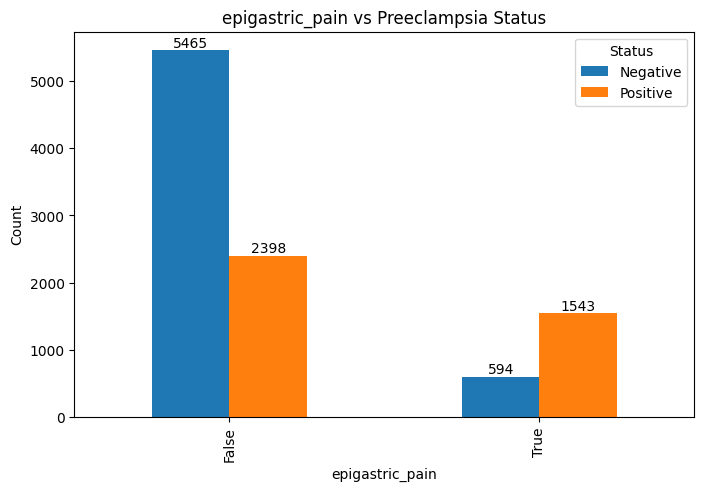


edema vs Target
Counts:
 preeclampsia_status  Negative  Positive
edema                                  
False                    4235      1124
True                     1824      2817

Percentages:
 preeclampsia_status  Negative  Positive
edema                                  
False                    79.0      21.0
True                     39.3      60.7


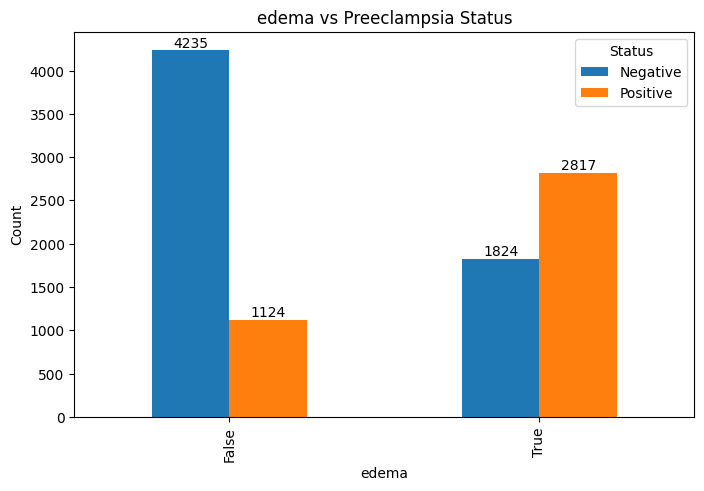


nausea_vomiting vs Target
Counts:
 preeclampsia_status  Negative  Positive
nausea_vomiting                        
False                    4552      2519
True                     1507      1422

Percentages:
 preeclampsia_status  Negative  Positive
nausea_vomiting                        
False                    64.4      35.6
True                     51.5      48.5


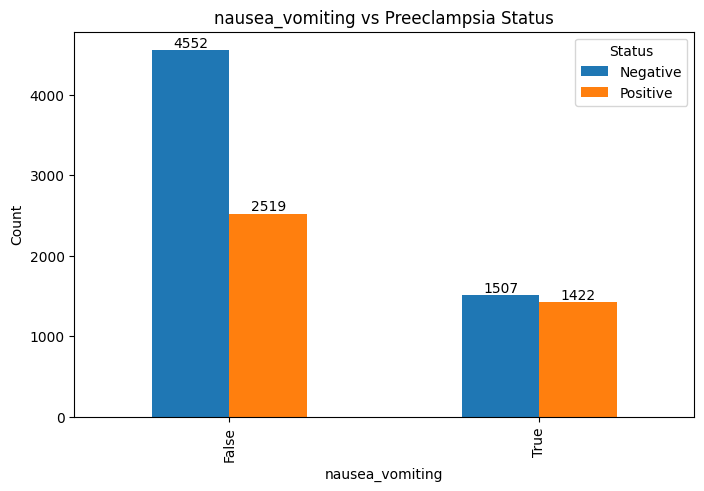


hellp_syndrome vs Target
Counts:
 preeclampsia_status  Negative  Positive
hellp_syndrome                         
False                    6059      3449
True                        0       492

Percentages:
 preeclampsia_status  Negative  Positive
hellp_syndrome                         
False                    63.7      36.3
True                      0.0     100.0


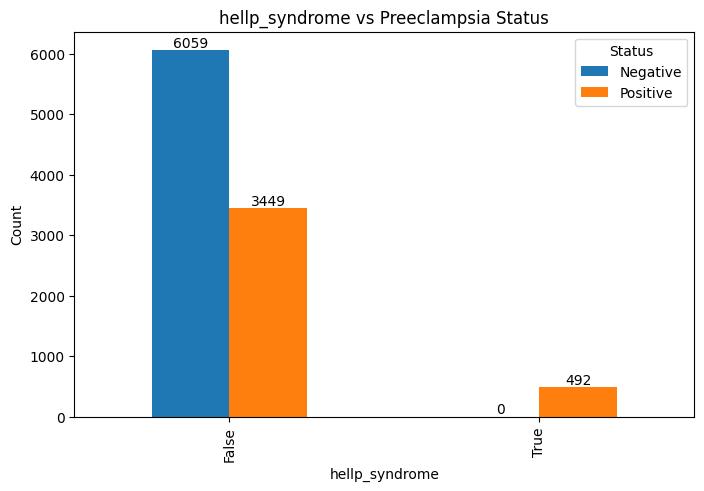


eclampsia vs Target
Counts:
 preeclampsia_status  Negative  Positive
eclampsia                              
False                    6059      3863
True                        0        78

Percentages:
 preeclampsia_status  Negative  Positive
eclampsia                              
False                    61.1      38.9
True                      0.0     100.0


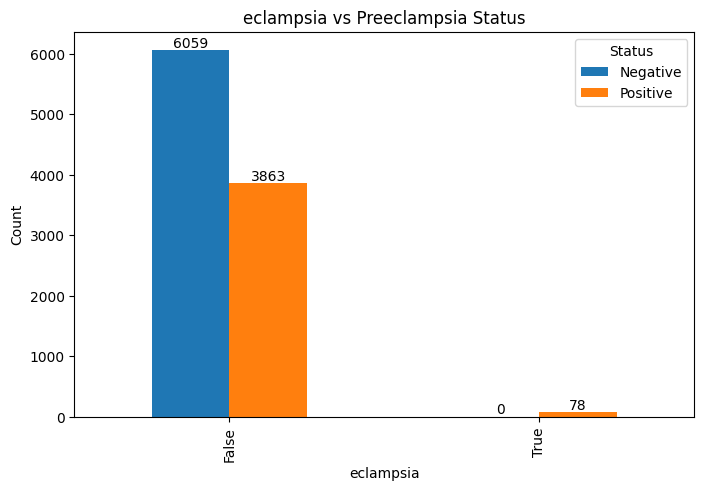


fetal_growth_restriction vs Target
Counts:
 preeclampsia_status       Negative  Positive
fetal_growth_restriction                    
False                         5774      3176
True                           285       765

Percentages:
 preeclampsia_status       Negative  Positive
fetal_growth_restriction                    
False                         64.5      35.5
True                          27.1      72.9


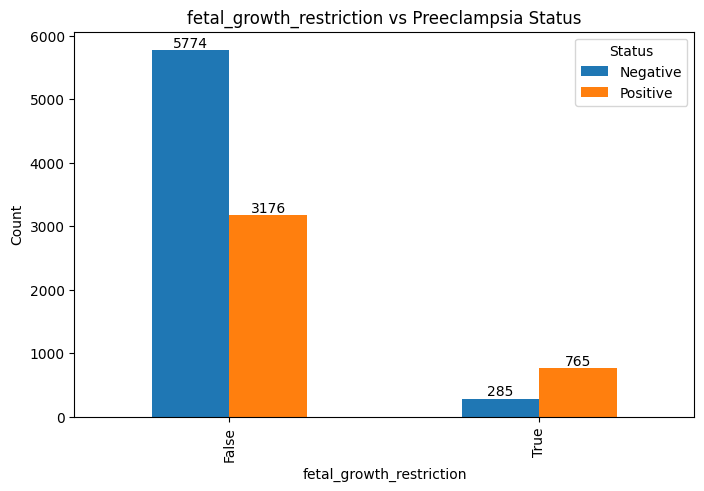


placental_abruption vs Target
Counts:
 preeclampsia_status  Negative  Positive
placental_abruption                    
False                    6059      3824
True                        0       117

Percentages:
 preeclampsia_status  Negative  Positive
placental_abruption                    
False                    61.3      38.7
True                      0.0     100.0


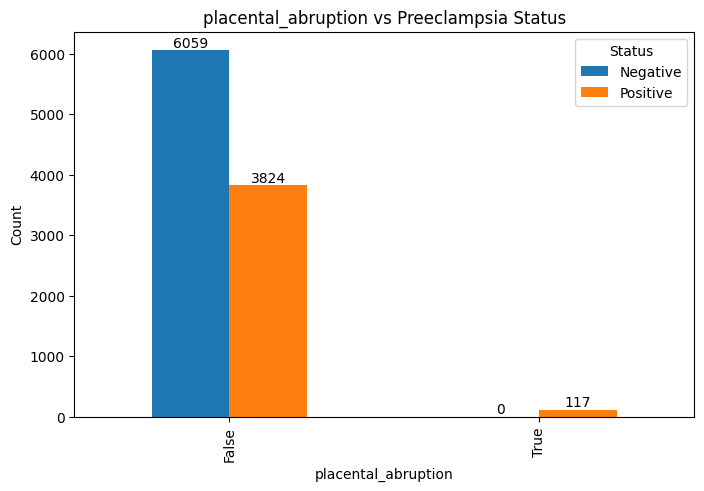


acute_kidney_injury vs Target
Counts:
 preeclampsia_status  Negative  Positive
acute_kidney_injury                    
False                    6059      3814
True                        0       127

Percentages:
 preeclampsia_status  Negative  Positive
acute_kidney_injury                    
False                    61.4      38.6
True                      0.0     100.0


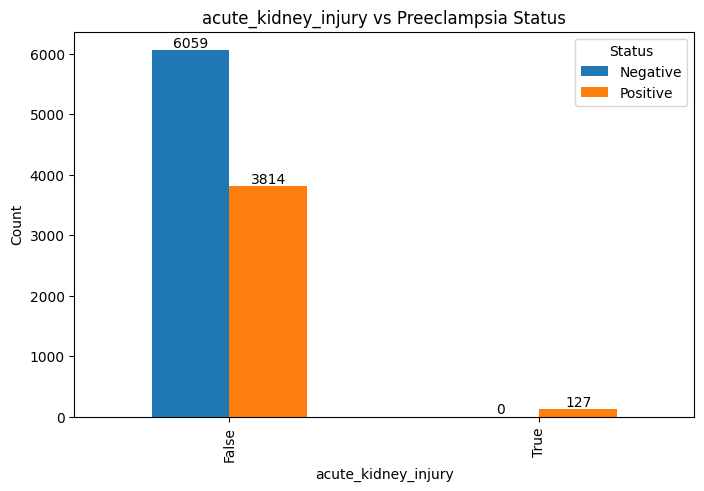


pulmonary_edema vs Target
Counts:
 preeclampsia_status  Negative  Positive
pulmonary_edema                        
False                    6059      3849
True                        0        92

Percentages:
 preeclampsia_status  Negative  Positive
pulmonary_edema                        
False                    61.2      38.8
True                      0.0     100.0


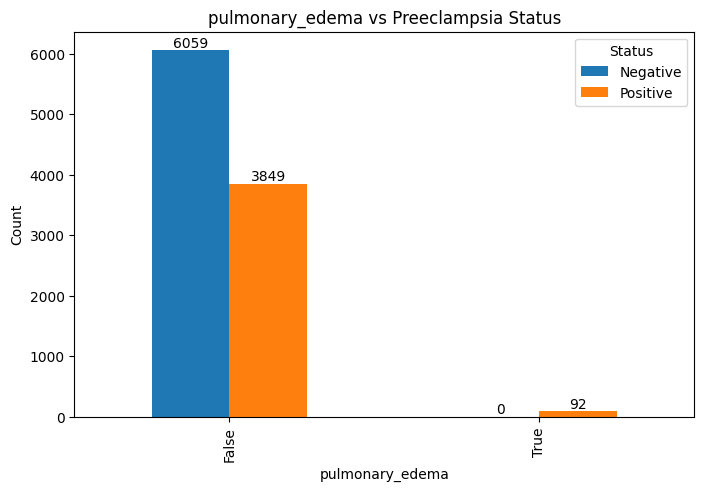


stroke vs Target
Counts:
 preeclampsia_status  Negative  Positive
stroke                                 
False                    6059      3937
True                        0         4

Percentages:
 preeclampsia_status  Negative  Positive
stroke                                 
False                    60.6      39.4
True                      0.0     100.0


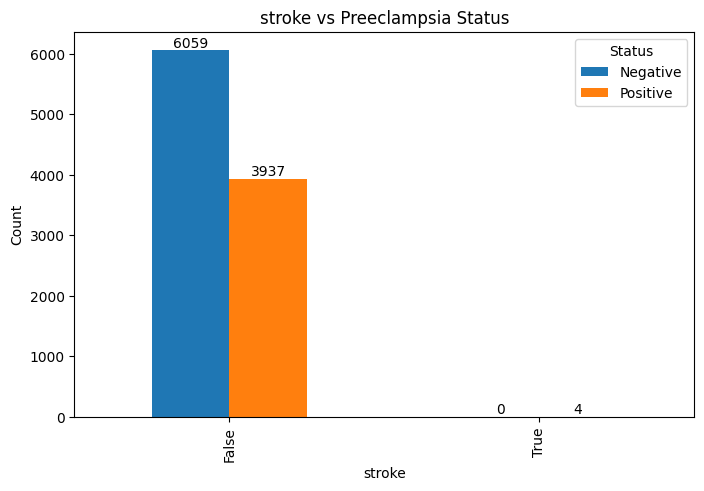

In [43]:
for col in categorical_cols:
    cross_count = pd.crosstab(data[col], data['preeclampsia_status'])
    cross_pct = pd.crosstab(data[col], data['preeclampsia_status'], normalize='index') * 100

    print(f"\n{col} vs Target")
    print("Counts:\n", cross_count)
    print("\nPercentages:\n", cross_pct.round(1))

    ax = cross_count.plot(kind='bar', figsize=(8,5))

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(f'{col} vs Preeclampsia Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Status')
    plt.show()

Counts:
 preeclampsia_status  Negative  Positive
severity                               
Mild                        0       836
Severe                      0      3105
safe                     6059         0

Percentages:
 preeclampsia_status  Negative  Positive
severity                               
Mild                      0.0     100.0
Severe                    0.0     100.0
safe                    100.0       0.0


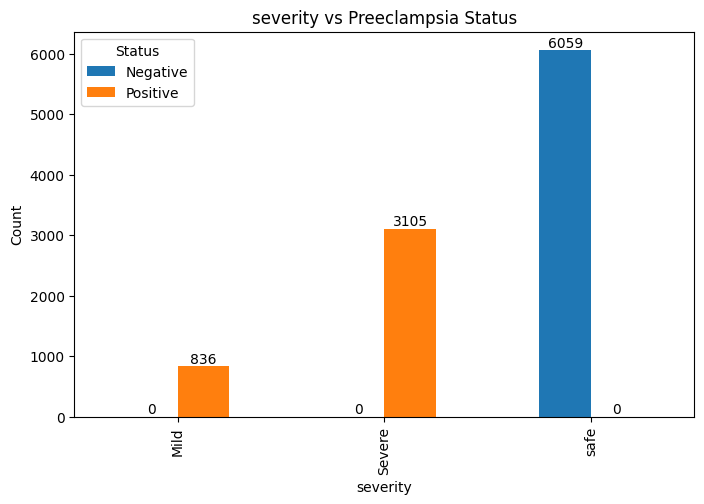

Counts:
 preeclampsia_status  Negative  Positive
hellp_syndrome                         
False                    6059      3449
True                        0       492

Percentages:
 preeclampsia_status  Negative  Positive
hellp_syndrome                         
False                    63.7      36.3
True                      0.0     100.0


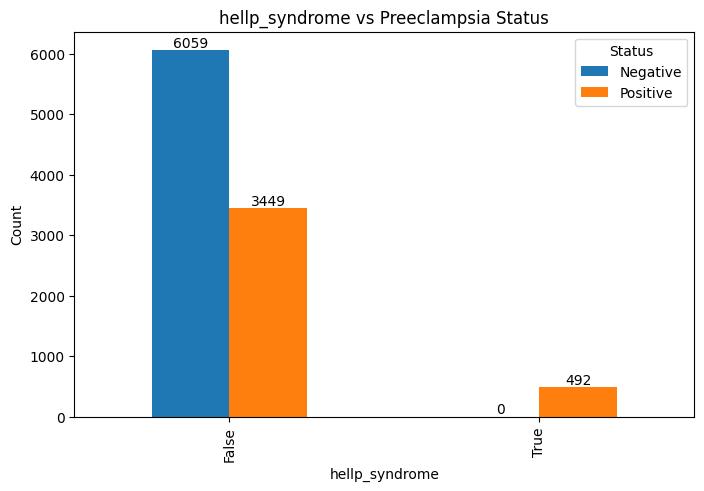

Counts:
 preeclampsia_status  Negative  Positive
eclampsia                              
False                    6059      3863
True                        0        78

Percentages:
 preeclampsia_status  Negative  Positive
eclampsia                              
False                    61.1      38.9
True                      0.0     100.0


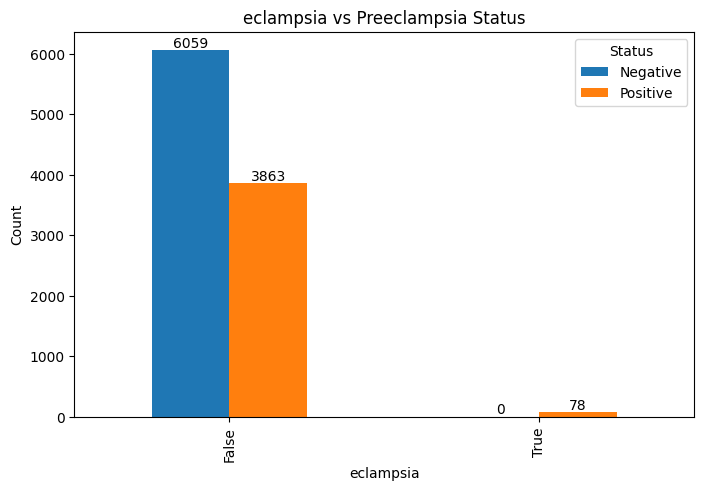

Counts:
 preeclampsia_status       Negative  Positive
fetal_growth_restriction                    
False                         5774      3176
True                           285       765

Percentages:
 preeclampsia_status       Negative  Positive
fetal_growth_restriction                    
False                         64.5      35.5
True                          27.1      72.9


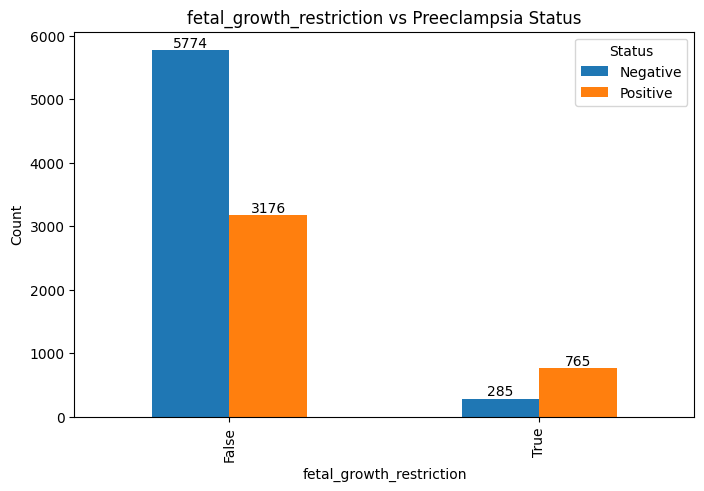

Counts:
 preeclampsia_status  Negative  Positive
placental_abruption                    
False                    6059      3824
True                        0       117

Percentages:
 preeclampsia_status  Negative  Positive
placental_abruption                    
False                    61.3      38.7
True                      0.0     100.0


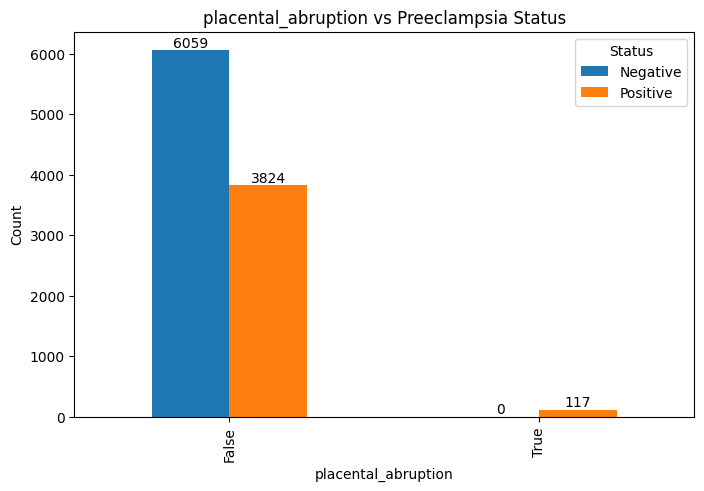

Counts:
 preeclampsia_status  Negative  Positive
acute_kidney_injury                    
False                    6059      3814
True                        0       127

Percentages:
 preeclampsia_status  Negative  Positive
acute_kidney_injury                    
False                    61.4      38.6
True                      0.0     100.0


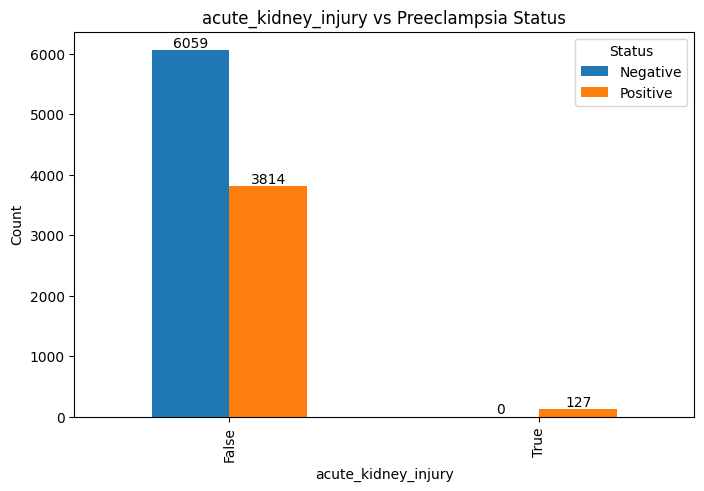

Counts:
 preeclampsia_status  Negative  Positive
pulmonary_edema                        
False                    6059      3849
True                        0        92

Percentages:
 preeclampsia_status  Negative  Positive
pulmonary_edema                        
False                    61.2      38.8
True                      0.0     100.0


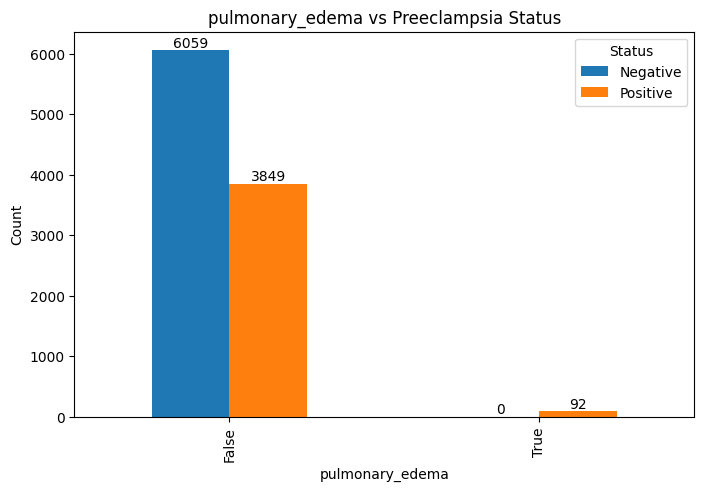

Counts:
 preeclampsia_status  Negative  Positive
stroke                                 
False                    6059      3937
True                        0         4

Percentages:
 preeclampsia_status  Negative  Positive
stroke                                 
False                    60.6      39.4
True                      0.0     100.0


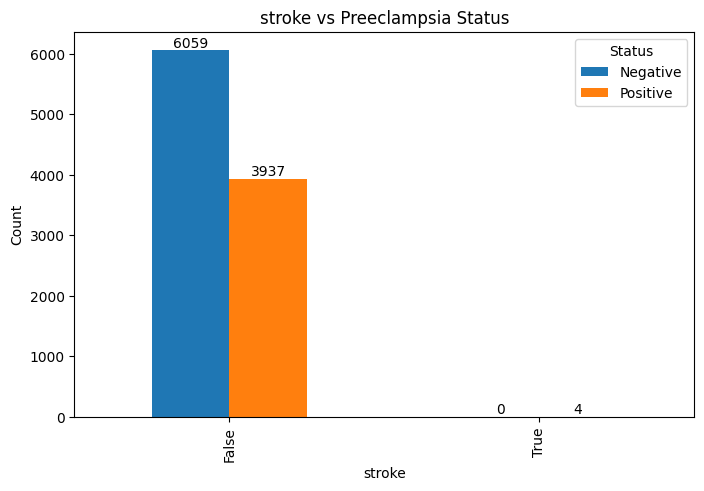

In [44]:
cols = [
    'severity',
    'hellp_syndrome',
    'eclampsia',
    'fetal_growth_restriction',
    'placental_abruption',
    'acute_kidney_injury',
    'pulmonary_edema',
    'stroke'
]

for col in cols:
    cross_count = pd.crosstab(data[col], data['preeclampsia_status'])
    cross_pct = pd.crosstab(data[col], data['preeclampsia_status'], normalize='index') * 100

    print("Counts:\n", cross_count) 
    print("\nPercentages:\n", cross_pct.round(1))
    ax = cross_count.plot(kind='bar', figsize=(8,5))
    
    for container in ax.containers:
        ax.bar_label(container)

    plt.title(f'{col} vs Preeclampsia Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Status')
    plt.show()

# drop unnecessary column

In [45]:
data.columns

Index(['patient_id', 'age', 'age_category', 'parity', 'gravida', 'bmi',
       'bmi_category', 'gestational_age_weeks', 'residence', 'education',
       'antenatal_visits', 'chronic_hypertension', 'pregestational_diabetes',
       'chronic_kidney_disease', 'multiple_pregnancy', 'previous_preeclampsia',
       'family_history_preeclampsia', 'antiphospholipid_syndrome',
       'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'proteinuria_24h_mg',
       'platelets_k_ul', 'ast_u_l', 'alt_u_l', 'creatinine_mg_dl', 'ldh_u_l',
       'uric_acid_mg_dl', 'hemoglobin_g_dl', 'preeclampsia_status', 'severity',
       'hellp_syndrome', 'eclampsia', 'headache', 'visual_disturbances',
       'epigastric_pain', 'edema', 'nausea_vomiting',
       'fetal_growth_restriction', 'placental_abruption',
       'acute_kidney_injury', 'pulmonary_edema', 'stroke', 'delivery_mode',
       'magnesium_sulfate_given', 'antihypertensive_given', 'maternal_outcome',
       'maternal_death'],
      dtype='object')

In [46]:
data.isna().sum()

patient_id                        0
age                               0
age_category                      0
parity                            0
gravida                           0
bmi                               0
bmi_category                      0
gestational_age_weeks             0
residence                         0
education                      2075
antenatal_visits                  0
chronic_hypertension              0
pregestational_diabetes           0
chronic_kidney_disease            0
multiple_pregnancy                0
previous_preeclampsia             0
family_history_preeclampsia       0
antiphospholipid_syndrome         0
systolic_bp_mmhg                  0
diastolic_bp_mmhg                 0
proteinuria_24h_mg                0
platelets_k_ul                    0
ast_u_l                           0
alt_u_l                           0
creatinine_mg_dl                  0
ldh_u_l                           0
uric_acid_mg_dl                   0
hemoglobin_g_dl             

In [47]:
y = data["preeclampsia_status"]
drop_cols = ["systolic_bp_mmhg","diastolic_bp_mmhg","proteinuria_24h_mg","patient_id","age_category","bmi_category","residence","education","antenatal_visits","preeclampsia_status","severity","hellp_syndrome","eclampsia","delivery_mode","maternal_outcome","maternal_death","placental_abruption","stroke","antihypertensive_given","magnesium_sulfate_given"]
data.drop(drop_cols, axis=1, inplace=True)

In [48]:
data.columns

Index(['age', 'parity', 'gravida', 'bmi', 'gestational_age_weeks',
       'chronic_hypertension', 'pregestational_diabetes',
       'chronic_kidney_disease', 'multiple_pregnancy', 'previous_preeclampsia',
       'family_history_preeclampsia', 'antiphospholipid_syndrome',
       'platelets_k_ul', 'ast_u_l', 'alt_u_l', 'creatinine_mg_dl', 'ldh_u_l',
       'uric_acid_mg_dl', 'hemoglobin_g_dl', 'headache', 'visual_disturbances',
       'epigastric_pain', 'edema', 'nausea_vomiting',
       'fetal_growth_restriction', 'acute_kidney_injury', 'pulmonary_edema'],
      dtype='object')

# convert some data from t/f to 0/1

In [49]:
bool_cols = data.select_dtypes(include=['bool']).columns.tolist()
print("Boolean columns to convert:", bool_cols)

for col in bool_cols:
    data[col] = data[col].astype(int)

Boolean columns to convert: ['chronic_hypertension', 'pregestational_diabetes', 'chronic_kidney_disease', 'multiple_pregnancy', 'previous_preeclampsia', 'family_history_preeclampsia', 'antiphospholipid_syndrome', 'headache', 'visual_disturbances', 'epigastric_pain', 'edema', 'nausea_vomiting', 'fetal_growth_restriction', 'acute_kidney_injury', 'pulmonary_edema']


In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          10000 non-null  int64  
 1   parity                       10000 non-null  int64  
 2   gravida                      10000 non-null  int64  
 3   bmi                          10000 non-null  float64
 4   gestational_age_weeks        10000 non-null  int64  
 5   chronic_hypertension         10000 non-null  int64  
 6   pregestational_diabetes      10000 non-null  int64  
 7   chronic_kidney_disease       10000 non-null  int64  
 8   multiple_pregnancy           10000 non-null  int64  
 9   previous_preeclampsia        10000 non-null  int64  
 10  family_history_preeclampsia  10000 non-null  int64  
 11  antiphospholipid_syndrome    10000 non-null  int64  
 12  platelets_k_ul               10000 non-null  float64
 13  ast_u_l          

# split data to x  and y 

In [51]:
X=data
y = (y == 'Positive').astype(int) 
print(y.value_counts())

preeclampsia_status
0    6059
1    3941
Name: count, dtype: int64


# split data into train test

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (8000, 27), Test size: (2000, 27)


# scale and encoding data

In [53]:
bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)
numerical_cols = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("Numerical features:", numerical_cols)

Numerical features: ['age', 'parity', 'gravida', 'bmi', 'gestational_age_weeks', 'chronic_hypertension', 'pregestational_diabetes', 'chronic_kidney_disease', 'multiple_pregnancy', 'previous_preeclampsia', 'family_history_preeclampsia', 'antiphospholipid_syndrome', 'platelets_k_ul', 'ast_u_l', 'alt_u_l', 'creatinine_mg_dl', 'ldh_u_l', 'uric_acid_mg_dl', 'hemoglobin_g_dl', 'headache', 'visual_disturbances', 'epigastric_pain', 'edema', 'nausea_vomiting', 'fetal_growth_restriction', 'acute_kidney_injury', 'pulmonary_edema']


In [54]:
numeric_transformer = Pipeline(steps=[
    ("scaler", RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols)
    ],
    remainder="drop"
)


In [55]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

X_train_df = pd.DataFrame(
    X_train_processed,
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index
)
X_test_df = pd.DataFrame(
    X_test_processed,
    columns=preprocessor.get_feature_names_out(),
    index=X_test.index
)

X_train_df.head()

,num__age,num__parity,num__gravida,num__bmi,num__gestational_age_weeks,num__chronic_hypertension,num__pregestational_diabetes,num__chronic_kidney_disease,num__multiple_pregnancy,num__previous_preeclampsia,...,num__uric_acid_mg_dl,num__hemoglobin_g_dl,num__headache,num__visual_disturbances,num__epigastric_pain,num__edema,num__nausea_vomiting,num__fetal_growth_restriction,num__acute_kidney_injury,num__pulmonary_edema
539,-0.538462,0.000000,-0.333333,0.033333,-0.2,0.0,0.0,0.0,0.0,0.0,...,-0.181818,0.1875,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
196,0.307692,0.000000,0.000000,-0.366667,-1.6,0.0,0.0,0.0,0.0,1.0,...,1.272727,-0.1875,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
8824,0.076923,1.333333,1.666667,-0.800000,-1.6,0.0,0.0,0.0,0.0,0.0,...,0.181818,-1.3750,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7223,0.153846,1.000000,1.333333,-0.016667,0.8,0.0,0.0,0.0,0.0,0.0,...,-0.818182,0.6875,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9649,-0.461538,-0.333333,-0.333333,-0.150000,-1.2,0.0,0.0,0.0,0.0,0.0,...,-0.590909,-1.1875,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
X_train_processed = preprocessor.fit_transform(X_train)

In [57]:
X_test_processed = preprocessor.transform(X_test)

In [58]:
X_train_df.shape

(8000, 27)

In [59]:
X_test_df.shape

(2000, 27)

# Classification Models

Same organization as the GDM notebook: CV probability tuning, threshold selection by target recall, model evaluation, plots, comparison, and saving artifacts.

## Model Functions

In [60]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    fbeta_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

CLASS_LABELS = ["Negative", "Positive"]


def safe_index(X, idx):
    if hasattr(X, "iloc"):
        return X.iloc[idx]
    return X[idx]


def make_pipeline(model_builder, params, scaler_class=None):
    steps = []

    if scaler_class is not None:
        steps.append(("scaler", scaler_class()))

    steps.append(("model", model_builder(**params)))

    return Pipeline(steps)


def get_pos_prob(model, X):
    prob = model.predict_proba(X)
    return prob[:, 1]


def get_cv_prob(X, y, model_builder, params, scaler_class=None, cv_splits=5, random_state=1):
    y_series = pd.Series(y).reset_index(drop=True)

    if hasattr(X, "reset_index"):
        X_work = X.reset_index(drop=True)
    else:
        X_work = X

    model_prob = np.zeros(len(y_series))

    cv = StratifiedKFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=random_state
    )

    for train_idx, valid_idx in cv.split(X_work, y_series):
        X_tr = safe_index(X_work, train_idx)
        X_val = safe_index(X_work, valid_idx)
        y_tr = y_series.iloc[train_idx]

        model = make_pipeline(
            model_builder=model_builder,
            params=params,
            scaler_class=scaler_class
        )

        model.fit(X_tr, y_tr)
        model_prob[valid_idx] = get_pos_prob(model, X_val)

    return model_prob


def calculate_threshold_metrics(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.round(np.arange(0.01, 1.00, 0.01), 2)

    rows = []

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        recall = recall_score(y_true, y_pred, zero_division=0)
        precision = precision_score(y_true, y_pred, zero_division=0)
        accuracy = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        rows.append({
            "threshold": threshold,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "accuracy": accuracy,
            "recall": recall,
            "precision": precision,
            "specificity": specificity,
            "f1": f1,
            "f2": f2
        })

    return pd.DataFrame(rows)


def choose_best_threshold(threshold_results, target_recall=0.96, selection_metric="accuracy"):
    valid = threshold_results[
        threshold_results["recall"] >= target_recall
    ].copy()

    if len(valid) > 0:
        best_row = valid.sort_values(
            by=[selection_metric, "precision", "accuracy", "FP", "FN", "threshold"],
            ascending=[False, False, False, True, True, False]
        ).iloc[0]

        hit_target = True

    else:
        best_row = threshold_results.sort_values(
            by=["recall", selection_metric, "precision", "accuracy", "FP"],
            ascending=[False, False, False, False, True]
        ).iloc[0]

        hit_target = False

    return best_row, hit_target


def tune_model_with_threshold(
    X_train,
    y_train,
    model_builder,
    param_grid,
    scaler_class=None,
    target_recall=0.96,
    selection_metric="accuracy",
    thresholds=None,
    cv_splits=5,
    random_state=1,
    verbose=True
):
    all_rows = []
    threshold_tables = {}
    grid = list(ParameterGrid(param_grid))

    for i, params in enumerate(grid, start=1):
        try:
            model_prob = get_cv_prob(
                X=X_train,
                y=y_train,
                model_builder=model_builder,
                params=params,
                scaler_class=scaler_class,
                cv_splits=cv_splits,
                random_state=random_state
            )

            threshold_results = calculate_threshold_metrics(
                y_true=np.array(y_train),
                y_prob=model_prob,
                thresholds=thresholds
            )

            best_threshold_row, hit_target = choose_best_threshold(
                threshold_results=threshold_results,
                target_recall=target_recall,
                selection_metric=selection_metric
            )

            param_id = f"params_{i}"
            threshold_tables[param_id] = threshold_results

            row = {
                "param_id": param_id,
                **params,
                "best_threshold": best_threshold_row["threshold"],
                "hit_target_recall": hit_target,
                "CV_TP": int(best_threshold_row["TP"]),
                "CV_TN": int(best_threshold_row["TN"]),
                "CV_FP": int(best_threshold_row["FP"]),
                "CV_FN": int(best_threshold_row["FN"]),
                "CV_accuracy": best_threshold_row["accuracy"],
                "CV_recall": best_threshold_row["recall"],
                "CV_precision": best_threshold_row["precision"],
                "CV_specificity": best_threshold_row["specificity"],
                "CV_f1": best_threshold_row["f1"],
                "CV_f2": best_threshold_row["f2"],
                "CV_roc_auc": roc_auc_score(y_train, model_prob),
                "CV_pr_auc": average_precision_score(y_train, model_prob)
            }

            all_rows.append(row)

            if verbose:
                print(
                    f"Done {i}/{len(grid)} | "
                    f"Recall={row['CV_recall']:.4f} | "
                    f"Accuracy={row['CV_accuracy']:.4f} | "
                    f"Threshold={row['best_threshold']}"
                )

        except Exception as e:
            print(f"Skipped params {params} because of error: {e}")

    results_df = pd.DataFrame(all_rows)

    if results_df.empty:
        raise ValueError("No valid model configurations were successfully fitted.")

    valid_models = results_df[results_df["hit_target_recall"] == True].copy()
    metric_col = f"CV_{selection_metric}"

    if len(valid_models) > 0:
        best_model_row = valid_models.sort_values(
            by=[metric_col, "CV_precision", "CV_accuracy", "CV_FP", "CV_FN", "best_threshold"],
            ascending=[False, False, False, True, True, False]
        ).iloc[0]
    else:
        best_model_row = results_df.sort_values(
            by=["CV_recall", metric_col, "CV_precision", "CV_accuracy", "CV_FP"],
            ascending=[False, False, False, False, True]
        ).iloc[0]

    best_params = {
        key: best_model_row[key]
        for key in param_grid.keys()
    }

    best_threshold = float(best_model_row["best_threshold"])

    final_model = make_pipeline(
        model_builder=model_builder,
        params=best_params,
        scaler_class=scaler_class
    )

    final_model.fit(X_train, y_train)

    feature_names = list(X_train.columns) if hasattr(X_train, "columns") else None

    tuned_object = {
        "model": final_model,
        "best_params": best_params,
        "threshold": best_threshold,
        "cv_results": results_df.sort_values(
            by=["hit_target_recall", metric_col, "CV_recall", "CV_accuracy"],
            ascending=[False, False, False, False]
        ).reset_index(drop=True),
        "best_cv_row": best_model_row,
        "best_threshold_results": threshold_tables[best_model_row["param_id"]],
        "target_recall": target_recall,
        "selection_metric": selection_metric,
        "feature_names": feature_names
    }

    print("\nBest Params:")
    print(best_params)

    print("\nBest Threshold:")
    print(best_threshold)

    print("\nBest CV Row:")
    display(pd.DataFrame([best_model_row]))

    return tuned_object

In [61]:
def evaluate_tuned_model(tuned_object, X, y, dataset_name="Test"):
    model = tuned_object["model"]
    threshold = tuned_object["threshold"]

    y_prob = get_pos_prob(model, X)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    metrics = {
        "dataset": dataset_name,
        "threshold": threshold,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "accuracy": accuracy_score(y, y_pred),
        "recall": recall_score(y, y_pred, zero_division=0),
        "precision": precision_score(y, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "f1": f1_score(y, y_pred, zero_division=0),
        "f2": fbeta_score(y, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y, y_prob),
        "pr_auc": average_precision_score(y, y_prob)
    }

    print(f"{dataset_name} Metrics")
    print("-" * 40)
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")

    print("\nClassification Report:")
    print(classification_report(y, y_pred, target_names=CLASS_LABELS))

    prediction_df = X.copy()
    prediction_df["Actual_Preeclampsia"] = np.array(y)
    prediction_df["Preeclampsia_Probability"] = y_prob
    prediction_df["Predicted_Preeclampsia"] = y_pred

    return metrics, prediction_df


def plot_threshold_tuning(tuned_object):
    threshold_results = tuned_object["best_threshold_results"]
    best_threshold = tuned_object["threshold"]
    target_recall = tuned_object["target_recall"]

    plt.figure(figsize=(9, 5))

    plt.plot(threshold_results["threshold"], threshold_results["recall"], label="Recall")
    plt.plot(threshold_results["threshold"], threshold_results["precision"], label="Precision")
    plt.plot(threshold_results["threshold"], threshold_results["accuracy"], label="Accuracy")
    plt.plot(threshold_results["threshold"], threshold_results["f2"], label="F2")

    plt.axvline(best_threshold, linestyle="--", label=f"Best Threshold = {best_threshold}")
    plt.axhline(target_recall, linestyle="--", label=f"Target Recall = {target_recall}")

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Threshold Tuning")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_tuned(tuned_object, X, y):
    model = tuned_object["model"]
    threshold = tuned_object["threshold"]

    y_prob = get_pos_prob(model, X)
    y_pred = (y_prob >= threshold).astype(int)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y, y_pred),
        display_labels=CLASS_LABELS
    )

    disp.plot()
    plt.title(f"Confusion Matrix at Threshold = {threshold}")
    plt.tight_layout()
    plt.show()


def plot_roc_and_pr_curves(tuned_object, X, y):
    model = tuned_object["model"]
    y_prob = get_pos_prob(model, X)

    RocCurveDisplay.from_predictions(y, y_prob)
    plt.title("ROC Curve")
    plt.tight_layout()
    plt.show()

    PrecisionRecallDisplay.from_predictions(y, y_prob)
    plt.title("Precision-Recall Curve")
    plt.tight_layout()
    plt.show()


def plot_probability_distribution(tuned_object, X, y):
    model = tuned_object["model"]
    threshold = tuned_object["threshold"]

    y_prob = get_pos_prob(model, X)
    y_array = np.array(y)

    plt.figure(figsize=(9, 5))

    plt.hist(
        y_prob[y_array == 0],
        bins=30,
        alpha=0.6,
        label="Negative"
    )

    plt.hist(
        y_prob[y_array == 1],
        bins=30,
        alpha=0.6,
        label="Positive"
    )

    plt.axvline(threshold, linestyle="--", label=f"Threshold = {threshold}")

    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title("Probability Distribution by Actual Class")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_logistic_coefficients(tuned_object, top_n=None):
    model = tuned_object["model"]
    feature_names = tuned_object["feature_names"]

    if feature_names is None:
        print("Feature names are not available.")
        return

    final_estimator = model.named_steps["model"]

    if not hasattr(final_estimator, "coef_"):
        print("This plot is only available for linear models like Logistic Regression.")
        return

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": final_estimator.coef_[0]
    })

    coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

    if top_n is not None:
        coef_df = coef_df.head(top_n)

    coef_df = coef_df.sort_values("Coefficient")

    plt.figure(figsize=(9, 6))
    plt.barh(coef_df["Feature"], coef_df["Coefficient"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Coefficient")
    plt.title("Logistic Regression Coefficients")
    plt.tight_layout()
    plt.show()

    return coef_df


def plot_all_model_diagnostics(tuned_object, X, y):
    plot_threshold_tuning(tuned_object)
    plot_confusion_matrix_tuned(tuned_object, X, y)
    plot_roc_and_pr_curves(tuned_object, X, y)
    plot_probability_distribution(tuned_object, X, y)


def plot_model_comparison(metrics_df):
    plot_df = metrics_df.copy()

    metrics_to_plot = ["accuracy", "recall", "precision", "specificity", "f1", "f2", "roc_auc", "pr_auc"]

    for metric in metrics_to_plot:
        plt.figure(figsize=(9, 5))
        plt.bar(plot_df["dataset"], plot_df[metric])
        plt.ylim(0, 1.05)
        plt.xticks(rotation=45, ha="right")
        plt.ylabel(metric)
        plt.title(f"Model Comparison - {metric}")
        plt.tight_layout()
        plt.show()


def select_best_overall_model(metrics_df, target_recall=0.99):
    valid = metrics_df[metrics_df["recall"] >= target_recall].copy()

    if len(valid) > 0:
        best = valid.sort_values(
            by=["accuracy", "precision", "specificity", "f2"],
            ascending=[False, False, False, False]
        ).iloc[0]
        print(f"Selected from models with recall >= {target_recall}")
    else:
        best = metrics_df.sort_values(
            by=["recall", "accuracy", "precision", "specificity"],
            ascending=[False, False, False, False]
        ).iloc[0]
        print(f"No model reached recall >= {target_recall}. Selected highest recall instead.")

    return best

## Setup for Preeclampsia Modeling

In [62]:
# Using the already preprocessed data from the previous section
# X_train_df / X_test_df are already RobustScaler-transformed.
# So, scaler_class=None in the model tuning calls to avoid scaling twice.

x_train = X_train_df.copy()
x_test = X_test_df.copy()

TARGET_RECALL = 0.96
SELECTION_METRIC = "accuracy"

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("-" * 40)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)
print("\nTarget recall:", TARGET_RECALL)

x_train shape: (8000, 27)
y_train shape: (8000,)
----------------------------------------
x_test shape: (2000, 27)
y_test shape: (2000,)

Target recall: 0.96


## Logistic Regression

### Tuning Model

In [68]:
logistic_param_grid = {
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear", "saga"],
    "C": [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 5, 10],
    "class_weight": ["balanced", None]
}

logistic_tuned = tune_model_with_threshold(
    X_train=x_train,
    y_train=y_train,
    model_builder=lambda **params: LogisticRegression(
        random_state=1,
        max_iter=10000,
        **params
    ),
    param_grid=logistic_param_grid,
    scaler_class=None,
    target_recall=TARGET_RECALL,
    selection_metric=SELECTION_METRIC,
    cv_splits=5,
    random_state=1,
    verbose=True
)

Done 1/60 | Recall=0.9642 | Accuracy=0.9443 | Threshold=0.33
Done 2/60 | Recall=0.9623 | Accuracy=0.9313 | Threshold=0.42
Done 3/60 | Recall=0.9638 | Accuracy=0.9441 | Threshold=0.33
Done 4/60 | Recall=0.9600 | Accuracy=0.9483 | Threshold=0.27
Done 5/60 | Recall=0.9616 | Accuracy=0.9207 | Threshold=0.37
Done 6/60 | Recall=0.9600 | Accuracy=0.9483 | Threshold=0.27
Done 7/60 | Recall=0.9604 | Accuracy=0.9546 | Threshold=0.33
Done 8/60 | Recall=0.9616 | Accuracy=0.9431 | Threshold=0.39
Done 9/60 | Recall=0.9604 | Accuracy=0.9546 | Threshold=0.33
Done 10/60 | Recall=0.9607 | Accuracy=0.9539 | Threshold=0.26
Done 11/60 | Recall=0.9642 | Accuracy=0.9345 | Threshold=0.32
Done 12/60 | Recall=0.9610 | Accuracy=0.9540 | Threshold=0.26
Done 13/60 | Recall=0.9610 | Accuracy=0.9593 | Threshold=0.34
Done 14/60 | Recall=0.9616 | Accuracy=0.9526 | Threshold=0.38
Done 15/60 | Recall=0.9610 | Accuracy=0.9593 | Threshold=0.34
Done 16/60 | Recall=0.9600 | Accuracy=0.9590 | Threshold=0.27
Done 17/60 | Reca

,param_id,C,class_weight,penalty,solver,best_threshold,hit_target_recall,CV_TP,CV_TN,CV_FP,CV_FN,CV_accuracy,CV_recall,CV_precision,CV_specificity,CV_f1,CV_f2,CV_roc_auc,CV_pr_auc
58,params_59,10.0,None,l2,liblinear,0.36,True,3027,4715,132,126,0.96775,0.960038,0.958215,0.972767,0.959125,0.959673,0.99401,0.992883


### Best Model

In [69]:
logistic_test_metrics, logistic_predictions_df = evaluate_tuned_model(
    tuned_object=logistic_tuned,
    X=x_test,
    y=y_test,
    dataset_name="Logistic Regression Test"
)

logistic_predictions_df.head()

Logistic Regression Test Metrics
----------------------------------------
dataset: Logistic Regression Test
threshold: 0.3600
TP: 759
TN: 1176
FP: 36
FN: 29
accuracy: 0.9675
recall: 0.9632
precision: 0.9547
specificity: 0.9703
f1: 0.9589
f2: 0.9615
roc_auc: 0.9948
pr_auc: 0.9937

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.97      1212
    Positive       0.95      0.96      0.96       788

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



,num__age,num__parity,num__gravida,num__bmi,num__gestational_age_weeks,num__chronic_hypertension,num__pregestational_diabetes,num__chronic_kidney_disease,num__multiple_pregnancy,num__previous_preeclampsia,...,num__visual_disturbances,num__epigastric_pain,num__edema,num__nausea_vomiting,num__fetal_growth_restriction,num__acute_kidney_injury,num__pulmonary_edema,Actual_Preeclampsia,Preeclampsia_Probability,Predicted_Preeclampsia
8106,0.000000,0.666667,0.666667,0.633333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0.023642,0
2814,0.153846,-0.333333,-0.333333,0.950000,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.017550,0
7592,0.076923,0.000000,-0.333333,0.483333,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1,1.000000,1
5527,0.923077,0.666667,0.666667,-0.733333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0.000956,0
8323,-0.461538,2.000000,2.333333,1.100000,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0.000799,0


### Model Plots

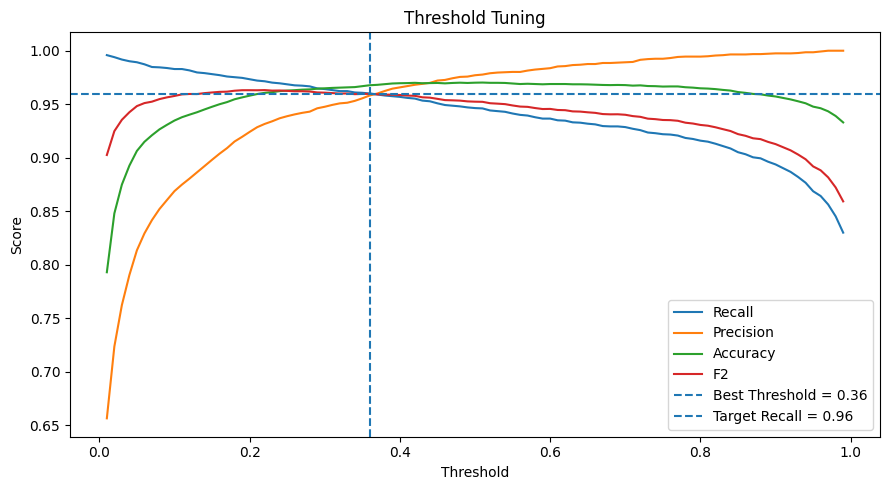

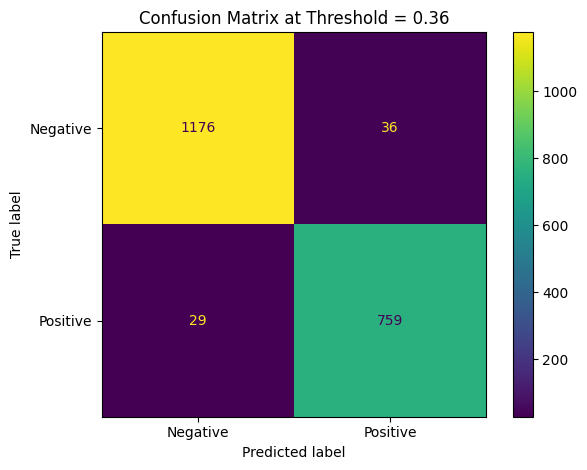

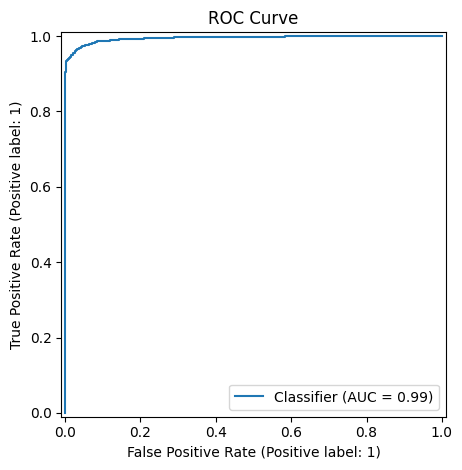

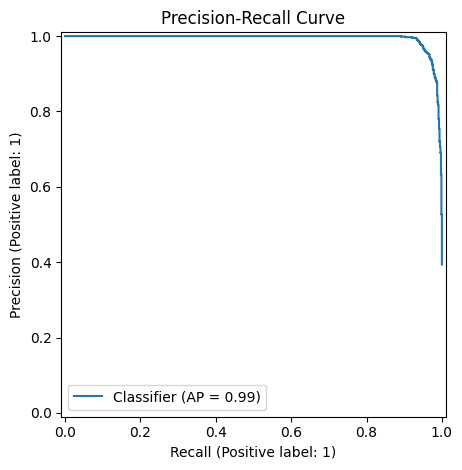

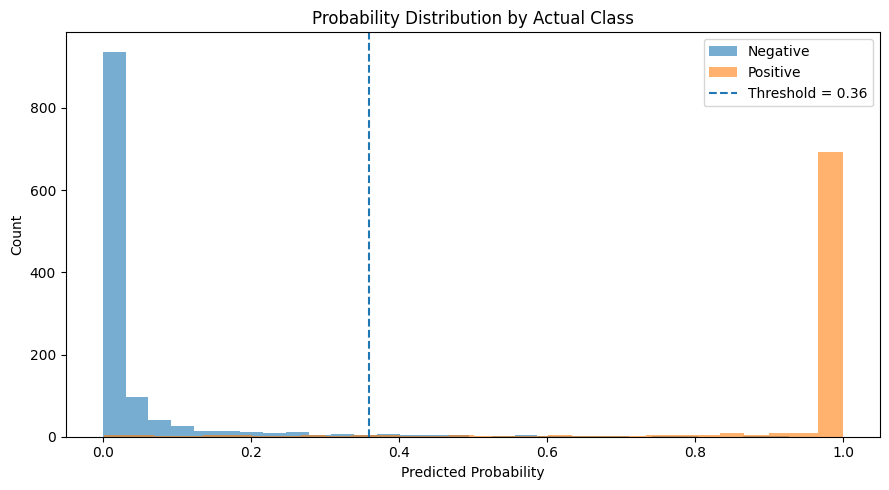

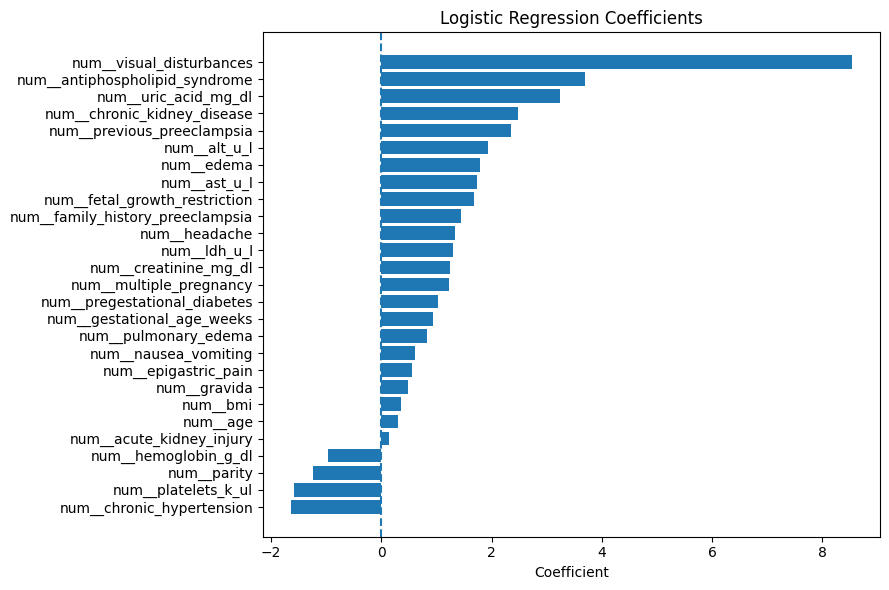

,Feature,Coefficient,Abs_Coefficient
5,num__chronic_hypertension,-1.634205,1.634205
12,num__platelets_k_ul,-1.579354,1.579354
1,num__parity,-1.235749,1.235749
18,num__hemoglobin_g_dl,-0.958263,0.958263
25,num__acute_kidney_injury,0.133773,0.133773
0,num__age,0.296743,0.296743
3,num__bmi,0.362187,0.362187
2,num__gravida,0.489645,0.489645
21,num__epigastric_pain,0.562166,0.562166
23,num__nausea_vomiting,0.620092,0.620092


In [70]:
plot_all_model_diagnostics(
    tuned_object=logistic_tuned,
    X=x_test,
    y=y_test
)

coef_df = plot_logistic_coefficients(
    tuned_object=logistic_tuned,
    top_n=None
)
coef_df

## SVM -- Linear

### Tuning Model

In [71]:
svm_linear_param_grid = {
    "kernel": ["linear"],
    "C": [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    "class_weight": ["balanced", None]
}

svm_linear_tuned = tune_model_with_threshold(
    X_train=x_train,
    y_train=y_train,
    model_builder=lambda **params: SVC(
        probability=True,
        random_state=1,
        **params
    ),
    param_grid=svm_linear_param_grid,
    scaler_class=None,
    target_recall=TARGET_RECALL,
    selection_metric=SELECTION_METRIC,
    cv_splits=5,
    random_state=1,
    verbose=True
)

Done 1/18 | Recall=0.9600 | Accuracy=0.9566 | Threshold=0.29
Done 2/18 | Recall=0.9600 | Accuracy=0.9570 | Threshold=0.28
Done 3/18 | Recall=0.9600 | Accuracy=0.9581 | Threshold=0.29
Done 4/18 | Recall=0.9604 | Accuracy=0.9606 | Threshold=0.31
Done 5/18 | Recall=0.9610 | Accuracy=0.9611 | Threshold=0.29
Done 6/18 | Recall=0.9610 | Accuracy=0.9611 | Threshold=0.29
Done 7/18 | Recall=0.9604 | Accuracy=0.9636 | Threshold=0.31
Done 8/18 | Recall=0.9607 | Accuracy=0.9617 | Threshold=0.29
Done 9/18 | Recall=0.9610 | Accuracy=0.9650 | Threshold=0.32
Done 10/18 | Recall=0.9604 | Accuracy=0.9665 | Threshold=0.34
Done 11/18 | Recall=0.9600 | Accuracy=0.9656 | Threshold=0.34
Done 12/18 | Recall=0.9600 | Accuracy=0.9663 | Threshold=0.34
Done 13/18 | Recall=0.9600 | Accuracy=0.9665 | Threshold=0.34
Done 14/18 | Recall=0.9600 | Accuracy=0.9675 | Threshold=0.36
Done 15/18 | Recall=0.9616 | Accuracy=0.9661 | Threshold=0.33
Done 16/18 | Recall=0.9600 | Accuracy=0.9681 | Threshold=0.36
Done 17/18 | Reca

,param_id,C,class_weight,kernel,best_threshold,hit_target_recall,CV_TP,CV_TN,CV_FP,CV_FN,CV_accuracy,CV_recall,CV_precision,CV_specificity,CV_f1,CV_f2,CV_roc_auc,CV_pr_auc
17,params_18,10.0,None,linear,0.36,True,3027,4720,127,126,0.968375,0.960038,0.959734,0.973798,0.959886,0.959977,0.993929,0.992853


### Best Model

In [72]:
svm_linear_test_metrics, svm_linear_predictions_df = evaluate_tuned_model(
    tuned_object=svm_linear_tuned,
    X=x_test,
    y=y_test,
    dataset_name="SVM Linear Test"
)

svm_linear_predictions_df.head()

SVM Linear Test Metrics
----------------------------------------
dataset: SVM Linear Test
threshold: 0.3600
TP: 757
TN: 1176
FP: 36
FN: 31
accuracy: 0.9665
recall: 0.9607
precision: 0.9546
specificity: 0.9703
f1: 0.9576
f2: 0.9594
roc_auc: 0.9947
pr_auc: 0.9936

Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97      1212
    Positive       0.95      0.96      0.96       788

    accuracy                           0.97      2000
   macro avg       0.96      0.97      0.96      2000
weighted avg       0.97      0.97      0.97      2000



,num__age,num__parity,num__gravida,num__bmi,num__gestational_age_weeks,num__chronic_hypertension,num__pregestational_diabetes,num__chronic_kidney_disease,num__multiple_pregnancy,num__previous_preeclampsia,...,num__visual_disturbances,num__epigastric_pain,num__edema,num__nausea_vomiting,num__fetal_growth_restriction,num__acute_kidney_injury,num__pulmonary_edema,Actual_Preeclampsia,Preeclampsia_Probability,Predicted_Preeclampsia
8106,0.000000,0.666667,0.666667,0.633333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0.028346,0
2814,0.153846,-0.333333,-0.333333,0.950000,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.020842,0
7592,0.076923,0.000000,-0.333333,0.483333,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1,1.000000,1
5527,0.923077,0.666667,0.666667,-0.733333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0.001237,0
8323,-0.461538,2.000000,2.333333,1.100000,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0.001571,0


## SVM Polynomial

### Tuning Model

In [74]:
svm_poly_param_grid = {
    "kernel": ["poly"],
    "C": [0.01, 0.1, 0.3, 1, 3],
    "degree": [2, 3, 4],
    "gamma": ["scale", "auto"],
    "coef0": [0, 1],
    "class_weight": ["balanced", None]
}

svm_poly_tuned = tune_model_with_threshold(
    X_train=x_train,
    y_train=y_train,
    model_builder=lambda **params: SVC(
        probability=True,
        random_state=1,
        **params
    ),
    param_grid=svm_poly_param_grid,
    scaler_class=None,
    target_recall=TARGET_RECALL,
    selection_metric=SELECTION_METRIC,
    cv_splits=5,
    random_state=1,
    verbose=True
)

Done 1/120 | Recall=0.9604 | Accuracy=0.9209 | Threshold=0.12
Done 2/120 | Recall=0.9616 | Accuracy=0.8416 | Threshold=0.08
Done 3/120 | Recall=0.9600 | Accuracy=0.9427 | Threshold=0.16
Done 4/120 | Recall=0.9629 | Accuracy=0.9274 | Threshold=0.14
Done 5/120 | Recall=0.9651 | Accuracy=0.8620 | Threshold=0.1
Done 6/120 | Recall=0.9829 | Accuracy=0.6551 | Threshold=0.1
Done 7/120 | Recall=0.9604 | Accuracy=0.9594 | Threshold=0.3
Done 8/120 | Recall=0.9616 | Accuracy=0.9574 | Threshold=0.28
Done 9/120 | Recall=0.9604 | Accuracy=0.9615 | Threshold=0.3
Done 10/120 | Recall=0.9613 | Accuracy=0.9584 | Threshold=0.29
Done 11/120 | Recall=0.9600 | Accuracy=0.9633 | Threshold=0.3
Done 12/120 | Recall=0.9604 | Accuracy=0.9597 | Threshold=0.3
Done 13/120 | Recall=0.9604 | Accuracy=0.9137 | Threshold=0.11
Done 14/120 | Recall=0.9600 | Accuracy=0.8391 | Threshold=0.08
Done 15/120 | Recall=0.9629 | Accuracy=0.9454 | Threshold=0.16
Done 16/120 | Recall=0.9626 | Accuracy=0.9271 | Threshold=0.14
Done 17

,param_id,C,class_weight,coef0,degree,gamma,kernel,best_threshold,hit_target_recall,CV_TP,...,CV_FP,CV_FN,CV_accuracy,CV_recall,CV_precision,CV_specificity,CV_f1,CV_f2,CV_roc_auc,CV_pr_auc
80,params_81,1.0,balanced,1,3,scale,poly,0.38,True,3027,...,110,126,0.9705,0.960038,0.964935,0.977306,0.96248,0.961013,0.994558,0.993576


### Best Model

In [75]:
svm_poly_test_metrics, svm_poly_predictions_df = evaluate_tuned_model(
    tuned_object=svm_poly_tuned,
    X=x_test,
    y=y_test,
    dataset_name="SVM Polynomial Test"
)

svm_poly_predictions_df.head()

SVM Polynomial Test Metrics
----------------------------------------
dataset: SVM Polynomial Test
threshold: 0.3800
TP: 760
TN: 1182
FP: 30
FN: 28
accuracy: 0.9710
recall: 0.9645
precision: 0.9620
specificity: 0.9752
f1: 0.9632
f2: 0.9640
roc_auc: 0.9956
pr_auc: 0.9946

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98      1212
    Positive       0.96      0.96      0.96       788

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



,num__age,num__parity,num__gravida,num__bmi,num__gestational_age_weeks,num__chronic_hypertension,num__pregestational_diabetes,num__chronic_kidney_disease,num__multiple_pregnancy,num__previous_preeclampsia,...,num__visual_disturbances,num__epigastric_pain,num__edema,num__nausea_vomiting,num__fetal_growth_restriction,num__acute_kidney_injury,num__pulmonary_edema,Actual_Preeclampsia,Preeclampsia_Probability,Predicted_Preeclampsia
8106,0.000000,0.666667,0.666667,0.633333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0.032707,0
2814,0.153846,-0.333333,-0.333333,0.950000,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.008158,0
7592,0.076923,0.000000,-0.333333,0.483333,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1,1.000000,1
5527,0.923077,0.666667,0.666667,-0.733333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0.039918,0
8323,-0.461538,2.000000,2.333333,1.100000,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0.000447,0


## SVM RBF

### Tuning Model

In [76]:
svm_rbf_param_grid = {
    "kernel": ["rbf"],
    "C": [0.01, 0.1, 0.3, 1, 3],
    "gamma": ["scale", "auto", 0.001, 0.03, 0.1],
    "class_weight": ["balanced", None]
}

svm_rbf_tuned = tune_model_with_threshold(
    X_train=x_train,
    y_train=y_train,
    model_builder=lambda **params: SVC(
        probability=True,
        random_state=1,
        **params
    ),
    param_grid=svm_rbf_param_grid,
    scaler_class=None,
    target_recall=TARGET_RECALL,
    selection_metric=SELECTION_METRIC,
    cv_splits=5,
    random_state=1,
    verbose=True
)

Done 1/50 | Recall=0.9600 | Accuracy=0.9524 | Threshold=0.23
Done 2/50 | Recall=0.9613 | Accuracy=0.9566 | Threshold=0.26
Done 3/50 | Recall=0.9686 | Accuracy=0.9038 | Threshold=0.16
Done 4/50 | Recall=0.9600 | Accuracy=0.9575 | Threshold=0.28
Done 5/50 | Recall=0.9613 | Accuracy=0.9484 | Threshold=0.21
Done 6/50 | Recall=0.9607 | Accuracy=0.9477 | Threshold=0.2
Done 7/50 | Recall=0.9623 | Accuracy=0.9551 | Threshold=0.24
Done 8/50 | Recall=0.9610 | Accuracy=0.9215 | Threshold=0.31
Done 9/50 | Recall=0.9632 | Accuracy=0.9549 | Threshold=0.24
Done 10/50 | Recall=0.9610 | Accuracy=0.9446 | Threshold=0.19
Done 11/50 | Recall=0.9600 | Accuracy=0.9647 | Threshold=0.33
Done 12/50 | Recall=0.9604 | Accuracy=0.9630 | Threshold=0.31
Done 13/50 | Recall=0.9600 | Accuracy=0.9474 | Threshold=0.25
Done 14/50 | Recall=0.9600 | Accuracy=0.9633 | Threshold=0.32
Done 15/50 | Recall=0.9600 | Accuracy=0.9655 | Threshold=0.34
Done 16/50 | Recall=0.9600 | Accuracy=0.9641 | Threshold=0.31
Done 17/50 | Recal

,param_id,C,class_weight,gamma,kernel,best_threshold,hit_target_recall,CV_TP,CV_TN,CV_FP,CV_FN,CV_accuracy,CV_recall,CV_precision,CV_specificity,CV_f1,CV_f2,CV_roc_auc,CV_pr_auc
49,params_50,3.0,None,0.1,rbf,0.4,True,3027,4748,99,126,0.971875,0.960038,0.96833,0.979575,0.964166,0.961685,0.994013,0.993103


### Best Model

In [77]:
svm_rbf_test_metrics, svm_rbf_predictions_df = evaluate_tuned_model(
    tuned_object=svm_rbf_tuned,
    X=x_test,
    y=y_test,
    dataset_name="SVM RBF Test"
)

svm_rbf_predictions_df.head()

SVM RBF Test Metrics
----------------------------------------
dataset: SVM RBF Test
threshold: 0.4000
TP: 756
TN: 1188
FP: 24
FN: 32
accuracy: 0.9720
recall: 0.9594
precision: 0.9692
specificity: 0.9802
f1: 0.9643
f2: 0.9613
roc_auc: 0.9949
pr_auc: 0.9941

Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.98      0.98      1212
    Positive       0.97      0.96      0.96       788

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



,num__age,num__parity,num__gravida,num__bmi,num__gestational_age_weeks,num__chronic_hypertension,num__pregestational_diabetes,num__chronic_kidney_disease,num__multiple_pregnancy,num__previous_preeclampsia,...,num__visual_disturbances,num__epigastric_pain,num__edema,num__nausea_vomiting,num__fetal_growth_restriction,num__acute_kidney_injury,num__pulmonary_edema,Actual_Preeclampsia,Preeclampsia_Probability,Predicted_Preeclampsia
8106,0.000000,0.666667,0.666667,0.633333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0.029855,0
2814,0.153846,-0.333333,-0.333333,0.950000,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.004211,0
7592,0.076923,0.000000,-0.333333,0.483333,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1,1.000000,1
5527,0.923077,0.666667,0.666667,-0.733333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0.043286,0
8323,-0.461538,2.000000,2.333333,1.100000,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0.009913,0


## Decision Tree

### Tuning Model

In [78]:
dt_param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced", None],
    "ccp_alpha": [0.0, 0.001, 0.003]
}


def build_decision_tree(**params):
    params = params.copy()

    if params.get("max_depth") is not None and not pd.isna(params.get("max_depth")):
        params["max_depth"] = int(params["max_depth"])
    else:
        params["max_depth"] = None

    params["min_samples_split"] = int(params["min_samples_split"])
    params["min_samples_leaf"] = int(params["min_samples_leaf"])

    return DecisionTreeClassifier(
        random_state=1,
        **params
    )


dt_tuned = tune_model_with_threshold(
    X_train=x_train,
    y_train=y_train,
    model_builder=build_decision_tree,
    param_grid=dt_param_grid,
    scaler_class=None,
    target_recall=TARGET_RECALL,
    selection_metric=SELECTION_METRIC,
    cv_splits=5,
    random_state=1,
    verbose=True
)

Done 1/648 | Recall=0.9854 | Accuracy=0.4980 | Threshold=0.08
Done 2/648 | Recall=0.9854 | Accuracy=0.4980 | Threshold=0.08
Done 3/648 | Recall=0.9854 | Accuracy=0.4979 | Threshold=0.08
Done 4/648 | Recall=0.9854 | Accuracy=0.4979 | Threshold=0.08
Done 5/648 | Recall=0.9854 | Accuracy=0.4979 | Threshold=0.08
Done 6/648 | Recall=0.9854 | Accuracy=0.4979 | Threshold=0.08
Done 7/648 | Recall=0.9851 | Accuracy=0.4999 | Threshold=0.08
Done 8/648 | Recall=0.9851 | Accuracy=0.4999 | Threshold=0.08
Done 9/648 | Recall=0.9851 | Accuracy=0.4999 | Threshold=0.08
Done 10/648 | Recall=0.9889 | Accuracy=0.5011 | Threshold=0.06
Done 11/648 | Recall=0.9889 | Accuracy=0.5012 | Threshold=0.06
Done 12/648 | Recall=0.9889 | Accuracy=0.5010 | Threshold=0.06
Done 13/648 | Recall=0.9889 | Accuracy=0.5015 | Threshold=0.06
Done 14/648 | Recall=0.9889 | Accuracy=0.5015 | Threshold=0.06
Done 15/648 | Recall=0.9892 | Accuracy=0.5015 | Threshold=0.06
Done 16/648 | Recall=0.9895 | Accuracy=0.5010 | Threshold=0.06
D

,param_id,ccp_alpha,class_weight,criterion,max_depth,min_samples_leaf,min_samples_split,best_threshold,hit_target_recall,CV_TP,...,CV_FP,CV_FN,CV_accuracy,CV_recall,CV_precision,CV_specificity,CV_f1,CV_f2,CV_roc_auc,CV_pr_auc
137,params_138,0.0,None,gini,NaN,1,10,0.16,True,3029,...,278,124,0.94975,0.960672,0.915936,0.942645,0.937771,0.951379,0.971026,0.951249


### Best Model

In [79]:
dt_test_metrics, dt_predictions_df = evaluate_tuned_model(
    tuned_object=dt_tuned,
    X=x_test,
    y=y_test,
    dataset_name="Decision Tree Test"
)

dt_predictions_df.head()

Decision Tree Test Metrics
----------------------------------------
dataset: Decision Tree Test
threshold: 0.1600
TP: 745
TN: 1147
FP: 65
FN: 43
accuracy: 0.9460
recall: 0.9454
precision: 0.9198
specificity: 0.9464
f1: 0.9324
f2: 0.9402
roc_auc: 0.9664
pr_auc: 0.9484

Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.95      0.96      1212
    Positive       0.92      0.95      0.93       788

    accuracy                           0.95      2000
   macro avg       0.94      0.95      0.94      2000
weighted avg       0.95      0.95      0.95      2000



,num__age,num__parity,num__gravida,num__bmi,num__gestational_age_weeks,num__chronic_hypertension,num__pregestational_diabetes,num__chronic_kidney_disease,num__multiple_pregnancy,num__previous_preeclampsia,...,num__visual_disturbances,num__epigastric_pain,num__edema,num__nausea_vomiting,num__fetal_growth_restriction,num__acute_kidney_injury,num__pulmonary_edema,Actual_Preeclampsia,Preeclampsia_Probability,Predicted_Preeclampsia
8106,0.000000,0.666667,0.666667,0.633333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0.0,0
2814,0.153846,-0.333333,-0.333333,0.950000,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.0,0
7592,0.076923,0.000000,-0.333333,0.483333,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1,1.0,1
5527,0.923077,0.666667,0.666667,-0.733333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0.0,0
8323,-0.461538,2.000000,2.333333,1.100000,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0


## Random Forest

### Tuning Model

In [80]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "criterion": ["gini", "entropy"],
    "max_depth": [4, 6, 8],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", "balanced_subsample"]
}


def build_random_forest(**params):
    params = params.copy()

    if params.get("max_depth") is not None and not pd.isna(params.get("max_depth")):
        params["max_depth"] = int(params["max_depth"])
    else:
        params["max_depth"] = None

    params["n_estimators"] = int(params["n_estimators"])
    params["min_samples_split"] = int(params["min_samples_split"])
    params["min_samples_leaf"] = int(params["min_samples_leaf"])

    return RandomForestClassifier(
        random_state=1,
        n_jobs=-1,
        **params
    )


rf_tuned = tune_model_with_threshold(
    X_train=x_train,
    y_train=y_train,
    model_builder=build_random_forest,
    param_grid=rf_param_grid,
    scaler_class=None,
    target_recall=TARGET_RECALL,
    selection_metric=SELECTION_METRIC,
    cv_splits=5,
    random_state=1,
    verbose=True
)

Done 1/648 | Recall=0.9607 | Accuracy=0.9523 | Threshold=0.28
Done 2/648 | Recall=0.9607 | Accuracy=0.9505 | Threshold=0.28
Done 3/648 | Recall=0.9607 | Accuracy=0.9521 | Threshold=0.28
Done 4/648 | Recall=0.9607 | Accuracy=0.9507 | Threshold=0.28
Done 5/648 | Recall=0.9607 | Accuracy=0.9524 | Threshold=0.28
Done 6/648 | Recall=0.9607 | Accuracy=0.9510 | Threshold=0.28
Done 7/648 | Recall=0.9607 | Accuracy=0.9525 | Threshold=0.28
Done 8/648 | Recall=0.9607 | Accuracy=0.9505 | Threshold=0.28
Done 9/648 | Recall=0.9607 | Accuracy=0.9525 | Threshold=0.28
Done 10/648 | Recall=0.9607 | Accuracy=0.9506 | Threshold=0.28
Done 11/648 | Recall=0.9607 | Accuracy=0.9524 | Threshold=0.28
Done 12/648 | Recall=0.9607 | Accuracy=0.9509 | Threshold=0.28
Done 13/648 | Recall=0.9600 | Accuracy=0.9515 | Threshold=0.28
Done 14/648 | Recall=0.9604 | Accuracy=0.9506 | Threshold=0.28
Done 15/648 | Recall=0.9600 | Accuracy=0.9515 | Threshold=0.28
Done 16/648 | Recall=0.9604 | Accuracy=0.9506 | Threshold=0.28
D

,param_id,class_weight,criterion,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,best_threshold,hit_target_recall,...,CV_FP,CV_FN,CV_accuracy,CV_recall,CV_precision,CV_specificity,CV_f1,CV_f2,CV_roc_auc,CV_pr_auc
612,params_613,balanced_subsample,entropy,8,log2,1,2,100,0.31,True,...,95,126,0.972375,0.960038,0.969571,0.9804,0.964781,0.96193,0.994341,0.993401


### Best Model

In [81]:
rf_test_metrics, rf_predictions_df = evaluate_tuned_model(
    tuned_object=rf_tuned,
    X=x_test,
    y=y_test,
    dataset_name="Random Forest Test"
)

rf_predictions_df.head()

Random Forest Test Metrics
----------------------------------------
dataset: Random Forest Test
threshold: 0.3100
TP: 758
TN: 1183
FP: 29
FN: 30
accuracy: 0.9705
recall: 0.9619
precision: 0.9632
specificity: 0.9761
f1: 0.9625
f2: 0.9622
roc_auc: 0.9940
pr_auc: 0.9930

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98      1212
    Positive       0.96      0.96      0.96       788

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



,num__age,num__parity,num__gravida,num__bmi,num__gestational_age_weeks,num__chronic_hypertension,num__pregestational_diabetes,num__chronic_kidney_disease,num__multiple_pregnancy,num__previous_preeclampsia,...,num__visual_disturbances,num__epigastric_pain,num__edema,num__nausea_vomiting,num__fetal_growth_restriction,num__acute_kidney_injury,num__pulmonary_edema,Actual_Preeclampsia,Preeclampsia_Probability,Predicted_Preeclampsia
8106,0.000000,0.666667,0.666667,0.633333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0.084750,0
2814,0.153846,-0.333333,-0.333333,0.950000,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.103875,0
7592,0.076923,0.000000,-0.333333,0.483333,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1,1.000000,1
5527,0.923077,0.666667,0.666667,-0.733333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0.044264,0
8323,-0.461538,2.000000,2.333333,1.100000,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0.058776,0


## Model Diagnostics

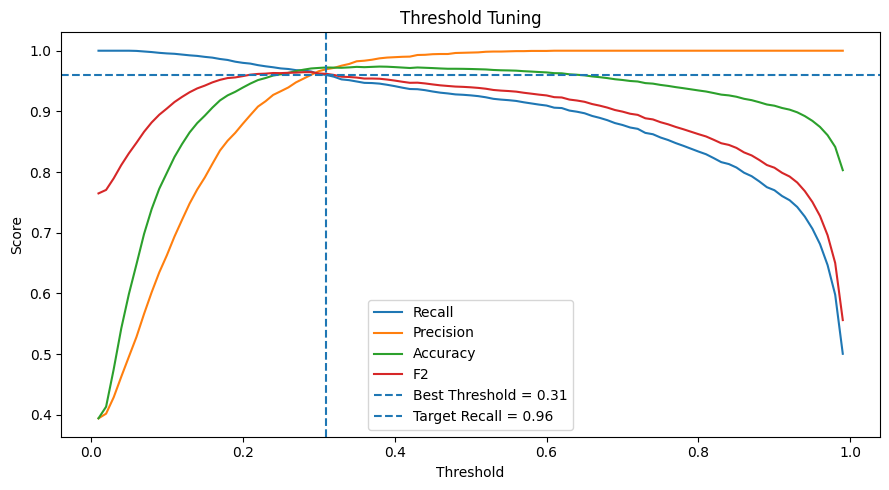

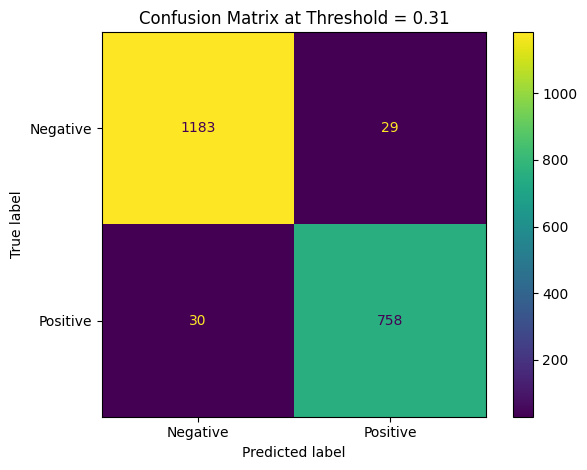

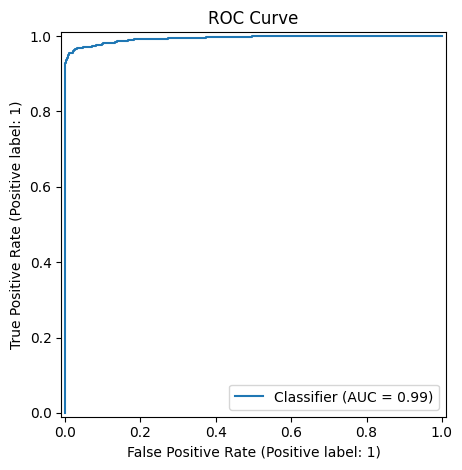

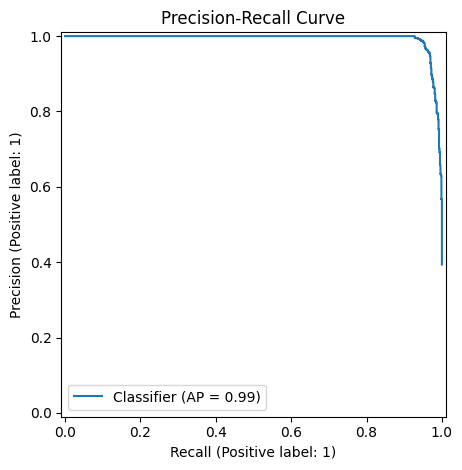

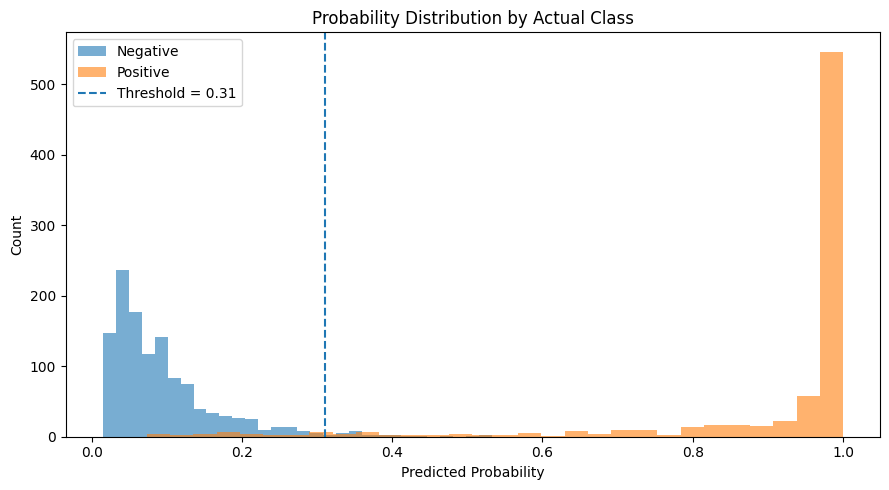

In [82]:
# Change tuned_object here to inspect any model:
# logistic_tuned, svm_linear_tuned, svm_poly_tuned, svm_rbf_tuned, dt_tuned, rf_tuned

plot_all_model_diagnostics(
    tuned_object=rf_tuned,
    X=x_test,
    y=y_test
)

# Comparison

In [83]:
all_test_metrics = pd.DataFrame([
    logistic_test_metrics,
    svm_linear_test_metrics,
    svm_poly_test_metrics,
    svm_rbf_test_metrics,
    dt_test_metrics,
    rf_test_metrics
])

all_test_metrics = all_test_metrics.sort_values(
    by=["recall", "accuracy", "precision", "specificity", "f2"],
    ascending=[False, False, False, False, False]
).reset_index(drop=True)

all_test_metrics

,dataset,threshold,TP,TN,FP,FN,accuracy,recall,precision,specificity,f1,f2,roc_auc,pr_auc
0,SVM Polynomial Test,0.38,760,1182,30,28,0.9710,0.964467,0.962025,0.975248,0.963245,0.963978,0.995623,0.994645
1,Logistic Regression Test,0.36,759,1176,36,29,0.9675,0.963198,0.954717,0.970297,0.958939,0.961490,0.994785,0.993676
2,Random Forest Test,0.31,758,1183,29,30,0.9705,0.961929,0.963151,0.976073,0.962540,0.962173,0.994032,0.992973
3,SVM Linear Test,0.36,757,1176,36,31,0.9665,0.960660,0.954603,0.970297,0.957622,0.959442,0.994678,0.993560
4,SVM RBF Test,0.40,756,1188,24,32,0.9720,0.959391,0.969231,0.980198,0.964286,0.961343,0.994920,0.994138
5,Decision Tree Test,0.16,745,1147,65,43,0.9460,0.945431,0.919753,0.946370,0.932416,0.940182,0.966411,0.948433


### Select Best Overall Model

In [84]:
best_overall_model = select_best_overall_model(
    metrics_df=all_test_metrics,
    target_recall=TARGET_RECALL
)

best_overall_model

Selected from models with recall >= 0.96


dataset        SVM Polynomial Test
threshold                     0.38
TP                             760
TN                            1182
FP                              30
FN                              28
accuracy                     0.971
recall                    0.964467
precision                 0.962025
specificity               0.975248
f1                        0.963245
f2                        0.963978
roc_auc                   0.995623
pr_auc                    0.994645
Name: 0, dtype: object

### Comparison Plot

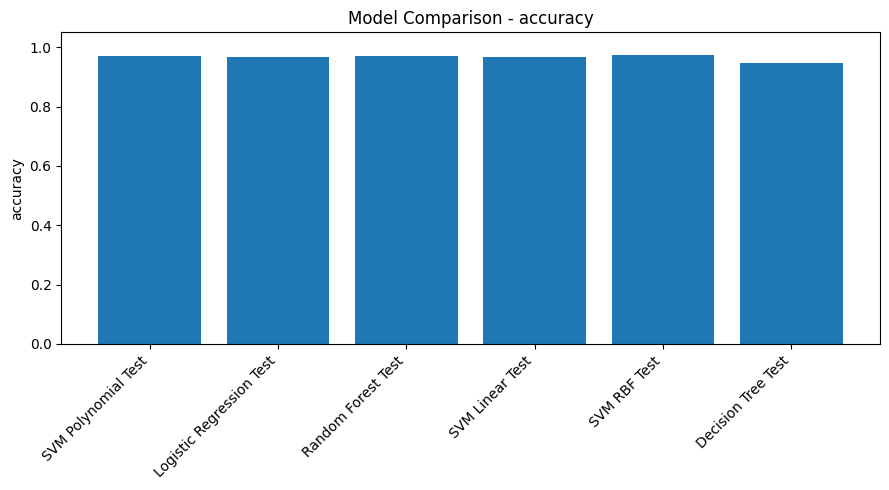

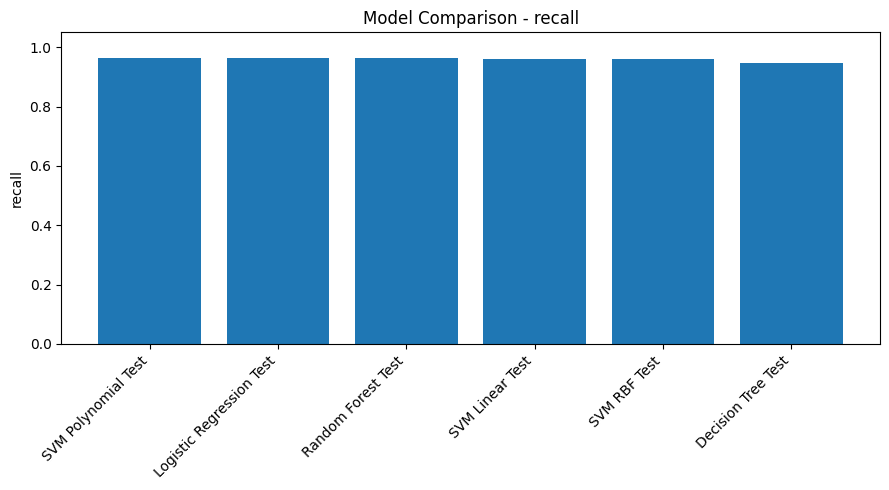

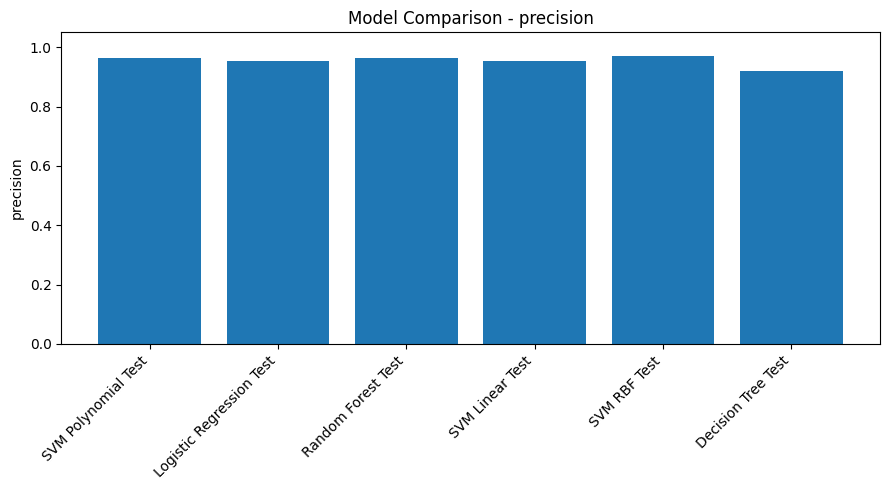

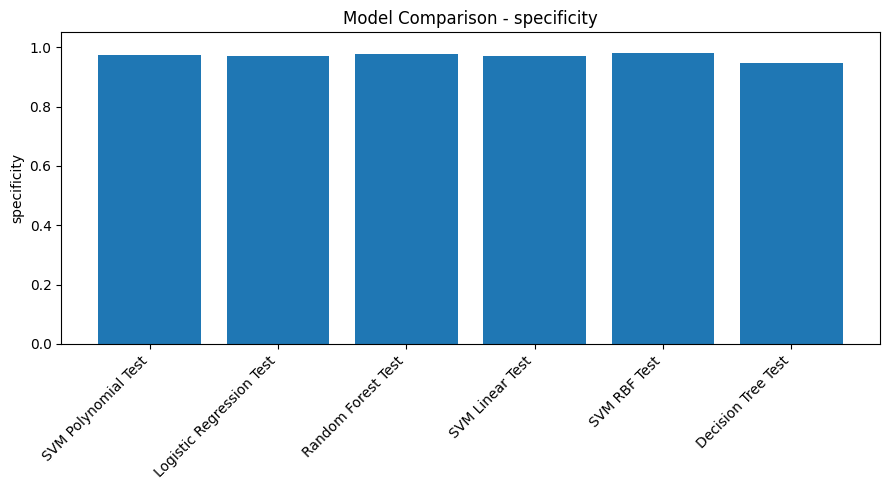

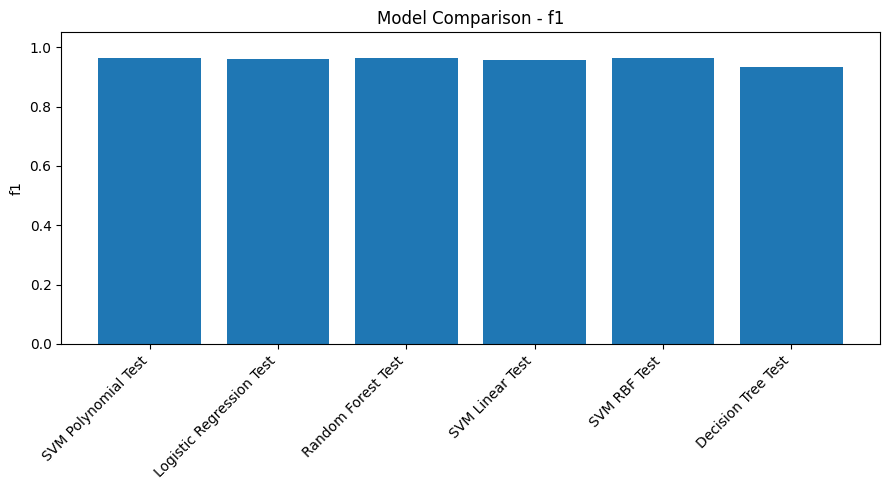

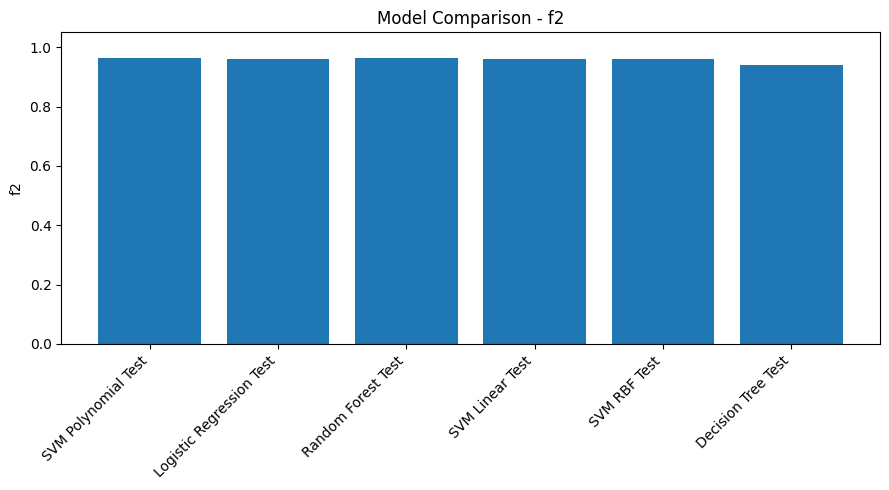

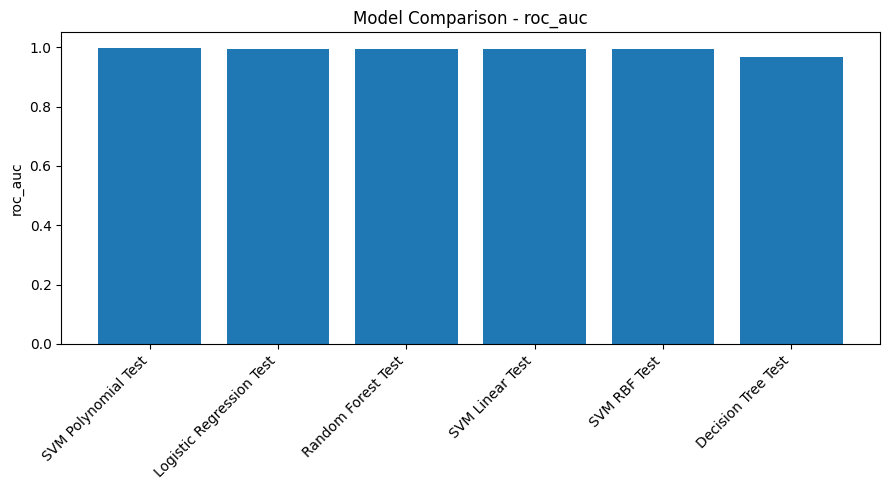

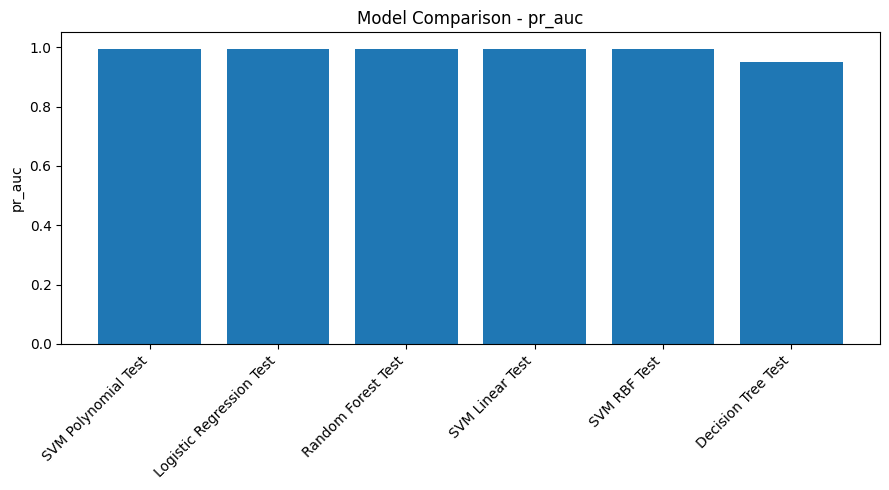

In [85]:
plot_model_comparison(all_test_metrics)

# Save Models

In [86]:
os.makedirs("saved_models_preeclampsia", exist_ok=True)

all_tuned_models = {
    "logistic_regression": logistic_tuned,
    "svm_linear": svm_linear_tuned,
    "svm_poly": svm_poly_tuned,
    "svm_rbf": svm_rbf_tuned,
    "decision_tree": dt_tuned,
    "random_forest": rf_tuned
}

models_artifact = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "target_recall": TARGET_RECALL,
    "selection_metric": SELECTION_METRIC,
    "models": {}
}

for model_name, tuned_obj in all_tuned_models.items():
    artifact = {
        "model_name": model_name,
        "model": tuned_obj["model"],
        "threshold": tuned_obj["threshold"],
        "best_params": tuned_obj["best_params"],
        "target_recall": tuned_obj["target_recall"],
        "selection_metric": tuned_obj["selection_metric"],
        "feature_names": tuned_obj["feature_names"]
    }

    file_path = f"saved_models_preeclampsia/{model_name}_artifact.pkl"
    joblib.dump(artifact, file_path)

    models_artifact["models"][model_name] = file_path

    print(f"Saved {model_name} -> {file_path}")

joblib.dump(models_artifact, "saved_models_preeclampsia/all_models_index.pkl")

print("\nSaved all models index -> saved_models_preeclampsia/all_models_index.pkl")

Saved logistic_regression -> saved_models_preeclampsia/logistic_regression_artifact.pkl
Saved svm_linear -> saved_models_preeclampsia/svm_linear_artifact.pkl
Saved svm_poly -> saved_models_preeclampsia/svm_poly_artifact.pkl
Saved svm_rbf -> saved_models_preeclampsia/svm_rbf_artifact.pkl
Saved decision_tree -> saved_models_preeclampsia/decision_tree_artifact.pkl
Saved random_forest -> saved_models_preeclampsia/random_forest_artifact.pkl

Saved all models index -> saved_models_preeclampsia/all_models_index.pkl


# Load Saved Models & Predict

In [63]:
def load_all_models(index_path="saved_models_preeclampsia/all_models_index.pkl"):
    index = joblib.load(index_path)

    loaded_models = {}

    for model_name, path in index["models"].items():
        loaded_models[model_name] = joblib.load(path)

    return loaded_models


def predict_all_saved_models(loaded_models, X):
    results = {}

    for model_name, artifact in loaded_models.items():
        model = artifact["model"]
        threshold = artifact["threshold"]
        feature_names = artifact["feature_names"]

        X_input = X.copy()

        if feature_names is not None:
            X_input = X_input[feature_names]

        probabilities = model.predict_proba(X_input)[:, 1]
        predictions = (probabilities >= threshold).astype(int)

        result_df = X_input.copy()
        result_df[f"{model_name}_Preeclampsia_Probability"] = probabilities
        result_df[f"{model_name}_Predicted_Preeclampsia"] = predictions

        results[model_name] = result_df

    return results


loaded_models = load_all_models("saved_models_preeclampsia/all_models_index.pkl")

all_predictions = predict_all_saved_models(
    loaded_models=loaded_models,
    X=x_test
)

all_predictions["random_forest"].head()

,num__age,num__parity,num__gravida,num__bmi,num__gestational_age_weeks,num__chronic_hypertension,num__pregestational_diabetes,num__chronic_kidney_disease,num__multiple_pregnancy,num__previous_preeclampsia,...,num__headache,num__visual_disturbances,num__epigastric_pain,num__edema,num__nausea_vomiting,num__fetal_growth_restriction,num__acute_kidney_injury,num__pulmonary_edema,random_forest_Preeclampsia_Probability,random_forest_Predicted_Preeclampsia
8106,0.000000,0.666667,0.666667,0.633333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.084750,0
2814,0.153846,-0.333333,-0.333333,0.950000,-0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.103875,0
7592,0.076923,0.000000,-0.333333,0.483333,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.000000,1
5527,0.923077,0.666667,0.666667,-0.733333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.044264,0
8323,-0.461538,2.000000,2.333333,1.100000,-0.8,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.058776,0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


def compare_saved_models(loaded_models, X_test, y_test):
    rows = []

    if y_test.dtype == "object":
        y_true = (y_test == "Positive").astype(int)
    else:
        y_true = y_test.copy()

    for model_name, artifact in loaded_models.items():
        model = artifact["model"]
        threshold = artifact["threshold"]
        feature_names = artifact["feature_names"]

        X_input = X_test.copy()

        if feature_names is not None:
            X_input = X_input[feature_names]

        probabilities = model.predict_proba(X_input)[:, 1]
        predictions = (probabilities >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()

        rows.append({
            "model": model_name,
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, predictions),
            "precision": precision_score(y_true, predictions, zero_division=0),
            "recall": recall_score(y_true, predictions),
            "f1": f1_score(y_true, predictions),
            "roc_auc": roc_auc_score(y_true, probabilities),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

    comparison_df = pd.DataFrame(rows)

    comparison_df = comparison_df.sort_values(
        by=["recall", "accuracy"],
        ascending=False
    ).reset_index(drop=True)

    return comparison_df

In [66]:
comparison_df = compare_saved_models(
    loaded_models=loaded_models,
    X_test=x_test,
    y_test=y_test
)

comparison_df

,model,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,svm_poly,0.38,0.9710,0.962025,0.964467,0.963245,0.995623,1182,30,28,760
1,logistic_regression,0.36,0.9675,0.954717,0.963198,0.958939,0.994785,1176,36,29,759
2,random_forest,0.31,0.9705,0.963151,0.961929,0.962540,0.994032,1183,29,30,758
3,svm_linear,0.36,0.9665,0.954603,0.960660,0.957622,0.994678,1176,36,31,757
4,svm_rbf,0.40,0.9720,0.969231,0.959391,0.964286,0.994920,1188,24,32,756
5,decision_tree,0.16,0.9460,0.919753,0.945431,0.932416,0.966411,1147,65,43,745


<Figure size 1400x600 with 0 Axes>

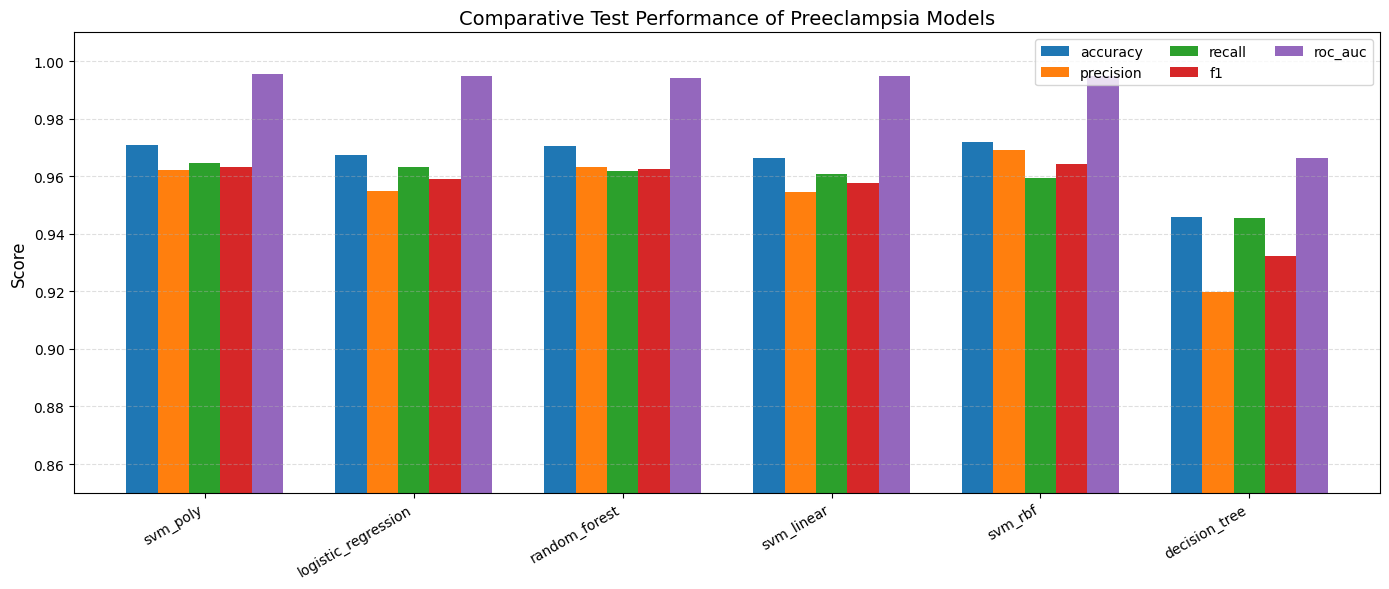

In [67]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]

plot_df = comparison_df.set_index("model")[metrics_to_plot]

plt.figure(figsize=(14, 6))

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.75
)

plt.title("Comparative Test Performance of Preeclampsia Models", fontsize=14)
plt.xlabel("")
plt.ylabel("Score", fontsize=12)

plt.xticks(rotation=30, ha="right")
plt.ylim(0.85, 1.01)

plt.legend(
    loc="upper right",
    ncol=3,
    frameon=True
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()